In [1]:
import pandas as pd
from sqlalchemy import create_engine, text
import redshift_connector
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from prophet import Prophet
from prophet.plot import plot_plotly
from prophet.plot import add_changepoints_to_plot
from prophet.diagnostics import cross_validation, performance_metrics

In [2]:
conn_args = {
    'host': 'cm-mks-helix-cluster-1.cgv0wa0jntot.us-west-2.redshift.amazonaws.com',
    'database': 'cm_sandbox_4',
    'port': 5439,
    'user': 'tribalvw',
    'password': 'R3$h!ft35263e3f!LxLc'
        }
# Establish connection
conn = redshift_connector.connect(**conn_args)

# Direct read (No S3 staging)
query = "SELECT * FROM af_tribal.Models_Advanced_Forecasting"
input_df = pd.read_sql(query, conn) 

# Access the data directly as a Pandas DataFrame
data = input_df

In [3]:
import numpy as np
import pandas as pd
from scipy.special import inv_boxcox
from scipy.stats import yeojohnson
from prophet import Prophet

# 1. Access and clean the initial data safely
# (Assumes 'data' DataFrame already exists in your environment)
golf_df = data[data['model'] == 'Golf'].copy()
golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])
golf_df = golf_df.sort_values(by='week_start', ascending=True)
golf_df = golf_df.iloc[1:-1]

golf_df_cleaned = golf_df.copy()

# List of all 4 numeric KPI columns
kpis = ['retailer_leads', 'visits', 'quality_arrivals', 'purchase_intents']

# Define specific IQR multipliers for outlier removal
iqr_multipliers = {
    "visits": 2.0,
    "quality_arrivals": 2.0,
    "purchase_intents": 2.0,
    "retailer_leads": 2.0,
}

# Loop through the items in the dictionary to flag outliers across all KPIs
for col, multiplier in iqr_multipliers.items():
    if col in golf_df_cleaned.columns:
        Q1 = golf_df_cleaned[col].quantile(0.25)
        Q3 = golf_df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        # Mask values outside bounds with NaN
        golf_df_cleaned[col] = golf_df_cleaned[col].mask(
            (golf_df_cleaned[col] < lower_bound) | (golf_df_cleaned[col] > upper_bound),
            np.nan,
        )

# Replace 0 with NaN for retailer_leads to prevent zero bias
if 'retailer_leads' in golf_df_cleaned.columns:
    golf_df_cleaned['retailer_leads'] = golf_df_cleaned['retailer_leads'].replace(0, np.nan)

# Linearly interpolate NaN values to make arrays finite across all KPIs for SciPy / Prophet
for col in kpis:
    golf_df_cleaned[col] = golf_df_cleaned[col].interpolate(method='linear')
    golf_df_cleaned[col] = golf_df_cleaned[col].ffill().bfill()

golf_df = golf_df_cleaned.copy()
golf_df['ds'] = pd.to_datetime(golf_df['week_start'])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = []
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # Apply correct transformation strategy based on current KPI
    if kpi == 'retailer_leads':
        transformed_data, current_lambda = yeojohnson(golf_df[kpi])
        golf_df[f'trans_{kpi}'] = transformed_data
    else:
        golf_df[f'trans_{kpi}'] = np.log1p(golf_df[kpi])
        current_lambda = None
    
    # Initialize Model with UK Holidays
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    
    # Fit model using the dynamically transformed column
    m.fit(golf_df[['ds', f'trans_{kpi}']].rename(columns={f'trans_{kpi}': 'y'}))
    
    # Create a dataframe covering BOTH History and Future timeline (48 weeks)
    full_timeline_df = m.make_future_dataframe(periods=48, freq='W-MON')
    
    # Generate Predictions
    forecast = m.predict(full_timeline_df)
    
    # Apply targeted Inverse Transformations back to original metrics scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        if kpi == 'retailer_leads':
            if current_lambda == 0:
                forecast[col] = np.exp(forecast[col]) - 1
            else:
                forecast[col] = np.where(
                    forecast[col] >= 0,
                    (forecast[col] * current_lambda + 1) ** (1 / current_lambda),
                    0
                )
        else:
            # Reverse Log transformation using (e^y - 1)
            forecast[col] = np.expm1(forecast[col])

    # Standardize time dimension names before merging to ensure strict column safety
    forecast = forecast.rename(columns={'ds': 'week_start'})
    forecast['week_start'] = pd.to_datetime(forecast['week_start'])
    golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])

    # Calculate MAPE using clean, explicit column merges on 'week_start'
    performance_df = forecast.merge(golf_df[['week_start', kpi]], on='week_start', how='inner')
    
    # Avoid zero-division errors if actuals are exactly 0
    performance_df = performance_df[performance_df[kpi] > 0]
    
    if not performance_df.empty:
        mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
        mape_scores[kpi] = mape
    else:
        mape_scores[kpi] = np.nan
     
    # Merge original actuals back for the full export dataset
    forecast_with_actuals = forecast.merge(
        golf_df[['week_start', kpi]], 
        on='week_start', 
        how='left'
    )

    # Select, rename and tag tracking dimensions
    forecast_clean = forecast_with_actuals[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', kpi]].copy()
    forecast_clean = forecast_clean.rename(columns={kpi: 'actual'})
    forecast_clean['KPI'] = kpi
    final_forecasts.append(forecast_clean)

# Generate final consolidated output DataFrame containing all 4 KPIs
final_output_df = pd.concat(final_forecasts, ignore_index=True)

# Print Out MAPE Performance Metrics for all 4 KPIs
#print("\n--- Model Performance (MAPE) ---")
#for kpi, score in mape_scores.items():
#    if not np.isnan(score):
#        print(f"{kpi}: {score:.2f}%")
#    else:
#        print(f"{kpi}: Could not calculate MAPE (Insufficient non-zero validation actuals)")


Processing model for: retailer_leads


18:29:14 - cmdstanpy - INFO - Chain [1] start processing
18:29:15 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: visits


18:29:15 - cmdstanpy - INFO - Chain [1] start processing
18:29:16 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: quality_arrivals


18:29:16 - cmdstanpy - INFO - Chain [1] start processing
18:29:17 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: purchase_intents


18:29:17 - cmdstanpy - INFO - Chain [1] start processing
18:29:18 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
import numpy as np


# Access the data directly as a Pandas DataFrame

golf_df = data[data['model'] == 'Golf']
golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])
golf_df = golf_df.sort_values(by='week_start', ascending=True)
golf_df = golf_df.iloc[1:-1]



# List of numeric KPI columns
kpis = ['retailer_leads']#,'visits', 'quality_arrivals', 'purchase_intents' ]

golf_df_cleaned = golf_df.copy()



# Create a df without outliers with diff treatment to leads
# Define specific IQR multipliers for each KPI
iqr_multipliers = {
    "visits": 2.0,
    "quality_arrivals": 2.0,
    "purchase_intents": 2.0,
    "retailer_leads": 2.0,  # Stricter bounds for retailer leads
}

# Loop through the items in the dictionary
for col, multiplier in iqr_multipliers.items():
    # 1. Calculate IQR bounds using the specific multiplier
    Q1 = golf_df_cleaned[col].quantile(0.25)
    Q3 = golf_df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    # 2. Mask values outside bounds with NaN
    golf_df_cleaned[col] = golf_df_cleaned[col].mask(
        (golf_df_cleaned[col] < lower_bound)
        | (golf_df_cleaned[col] > upper_bound),
        np.nan,
    )



golf_df_cleaned['retailer_leads'] = golf_df_cleaned['retailer_leads'].replace(0, np.nan)
golf_df = golf_df_cleaned.copy()
# 1. Data Preparation
golf_df['ds'] = pd.to_datetime(golf_df['week_start'])
kpis = ['retailer_leads']#,'visits', 'quality_arrivals', 'purchase_intents' ]


import numpy as np

# 1. Apply specific transformations per KPI
for kpi in kpis:
    if kpi == 'retailer_leads':
        golf_df[f'trans_{kpi}'] = np.cbrt(golf_df[kpi])
    else:
        golf_df[f'trans_{kpi}'] = np.log1p(golf_df[kpi])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = []
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # Initialize Model with UK Holidays
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    
    # Fit model using the dynamically transformed column
    m.fit(golf_df[['ds', f'trans_{kpi}']].rename(columns={f'trans_{kpi}': 'y'}))
    
    # 3. Create a dataframe covering BOTH History and Future
    full_timeline_df = m.make_future_dataframe(periods=48, freq='W-MON')
    
    # Generate Predictions
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation back to original scale based on KPI type
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        if kpi == 'retailer_leads':
            # Prevent negative bounds from squaring into false positive numbers
            forecast[col] = np.clip(forecast[col], a_min=0, a_max=None) ** 3
        else:
            forecast[col] = np.expm1(forecast[col])

    # 5. Calculate MAPE (on historical scale only)
    # Join historical actuals with the corresponding historical predictions
    performance_df = forecast.set_index('ds').join(golf_df.set_index('ds')[[kpi]], how='inner')
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
    mape_scores[kpi] = mape
     
    # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Formatting the output for Rivery/Export
    forecast = forecast.rename(columns={'ds': 'week_start'})
    golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])
    # MERGE ACTUALS: Join the original KPI column from Golf_df
    # Golf_df must have 'week_start' and the KPI column (e.g., 'visits')
    forecast_with_actuals = forecast.merge(
        golf_df[['week_start', kpi]], 
        on='week_start', 
        how='left'
    )

   # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Select columns and rename the KPI column (e.g., 'visits') to 'actual'
    forecast_clean = forecast_with_actuals[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', kpi]].copy()
    forecast_clean = forecast_clean.rename(columns={kpi: 'actual'})
    forecast_clean['KPI'] = kpi
    final_forecasts.append(forecast_clean)

   # 5. Final Output DataFrame
final_output_df = pd.concat(final_forecasts, ignore_index=True)


# 6. Output MAPE Results
#print("\n--- Model Performance (MAPE) ---")
#for kpi, score in mape_scores.items():
#    print(f"{kpi}: {score:.2f}%")




Processing model for: retailer_leads


18:31:56 - cmdstanpy - INFO - Chain [1] start processing
18:31:56 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
import numpy as np
import pandas as pd
from scipy.special import inv_boxcox
from scipy.stats import yeojohnson
from prophet import Prophet

# 1. Access and clean the initial data safely
# (Assumes 'data' DataFrame already exists in your environment)
golf_df = data[data['model'] == 'Golf'].copy()
golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])
golf_df = golf_df.sort_values(by='week_start', ascending=True)
golf_df = golf_df.iloc[1:-1]

golf_df_cleaned = golf_df.copy()

# List of numeric KPI columns (Uncomment others when you want to run all 4)
kpis = ['retailer_leads']  # ['retailer_leads', 'visits', 'quality_arrivals', 'purchase_intents']

# Define specific IQR multipliers for outlier removal
iqr_multipliers = {
    "visits": 2.0,
    "quality_arrivals": 2.0,
    "purchase_intents": 2.0,
    "retailer_leads": 2.0,
}

# Loop through the items in the dictionary to flag outliers
for col, multiplier in iqr_multipliers.items():
    if col in golf_df_cleaned.columns:
        Q1 = golf_df_cleaned[col].quantile(0.25)
        Q3 = golf_df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        # Mask values outside bounds with NaN
        golf_df_cleaned[col] = golf_df_cleaned[col].mask(
            (golf_df_cleaned[col] < lower_bound) | (golf_df_cleaned[col] > upper_bound),
            np.nan,
        )

# Replace 0 with NaN for retailer_leads to prevent zero bias
if 'retailer_leads' in golf_df_cleaned.columns:
    golf_df_cleaned['retailer_leads'] = golf_df_cleaned['retailer_leads'].replace(0, np.nan)

# Linearly interpolate NaN values to make the array finite for SciPy / Prophet
for col in kpis:
    golf_df_cleaned[col] = golf_df_cleaned[col].interpolate(method='linear')
    golf_df_cleaned[col] = golf_df_cleaned[col].ffill().bfill()

golf_df = golf_df_cleaned.copy()
golf_df['ds'] = pd.to_datetime(golf_df['week_start'])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = []
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # SYSTEM FIX: Handle transformations right inside the loop to avoid cross-cell context drops
    if kpi == 'retailer_leads':
        transformed_data, current_lambda = yeojohnson(golf_df[kpi])
        golf_df[f'trans_{kpi}'] = transformed_data
    else:
        golf_df[f'trans_{kpi}'] = np.log1p(golf_df[kpi])
        current_lambda = None
    
    # Initialize Model with UK Holidays
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    
    # Fit model using the dynamically transformed column
    m.fit(golf_df[['ds', f'trans_{kpi}']].rename(columns={f'trans_{kpi}': 'y'}))
    
    # Create a dataframe covering BOTH History and Future timeline (48 weeks)
    full_timeline_df = m.make_future_dataframe(periods=48, freq='W-MON')
    
    # Generate Predictions
    forecast = m.predict(full_timeline_df)
    
    # Apply targeted Inverse Transformations
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        if kpi == 'retailer_leads':
            if current_lambda == 0:
                forecast[col] = np.exp(forecast[col]) - 1
            else:
                forecast[col] = np.where(
                    forecast[col] >= 0,
                    (forecast[col] * current_lambda + 1) ** (1 / current_lambda),
                    0
                )
        else:
            # Reverse Log transformation using (e^y - 1)
            forecast[col] = np.expm1(forecast[col])

    # Standardize time dimension names before merging to ensure strict column safety
    forecast = forecast.rename(columns={'ds': 'week_start'})
    forecast['week_start'] = pd.to_datetime(forecast['week_start'])
    golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])

    # Calculate MAPE using clean, explicit column merges on 'week_start'
    performance_df = forecast.merge(golf_df[['week_start', kpi]], on='week_start', how='inner')
    
    # Avoid zero-division errors if actuals are exactly 0
    performance_df = performance_df[performance_df[kpi] > 0]
    
    if not performance_df.empty:
        mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
        mape_scores[kpi] = mape
    else:
        mape_scores[kpi] = np.nan
     
    # Merge original actuals back for the full export dataset
    forecast_with_actuals = forecast.merge(
        golf_df[['week_start', kpi]], 
        on='week_start', 
        how='left'
    )

    # Select, rename and tag tracking dimensions
    forecast_clean = forecast_with_actuals[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', kpi]].copy()
    forecast_clean = forecast_clean.rename(columns={kpi: 'actual'})
    forecast_clean['KPI'] = kpi
    final_forecasts.append(forecast_clean)

# Generate final consolidated output DataFrame
final_output_df = pd.concat(final_forecasts, ignore_index=True)

# Print Out MAPE Performance Metrics
#print("\n--- Model Performance (MAPE) ---")
#for kpi, score in mape_scores.items():
#    if not np.isnan(score):
#        print(f"{kpi}: {score:.2f}%")
#    else:
#        print(f"{kpi}: Could not calculate MAPE (Insufficient non-zero validation actuals)")


Processing model for: retailer_leads


18:32:17 - cmdstanpy - INFO - Chain [1] start processing
18:32:17 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
from scipy.stats import yeojohnson

# 1. Transform: It outputs the transformed array and the calculated optimal lambda
golf_df['trans_retailer_leads'], yj_lambda = yeojohnson(golf_df['retailer_leads'])

# 2. Fit and Forecast (inside your Prophet loop)
# ... [Prophet training & forecasting code runs here] ...

# 3. Inverse Transform: Use scipy's built-in inverse function
from scipy.special import inv_boxcox

for col in ['yhat', 'yhat_lower', 'yhat_upper']:
    # Yeo-Johnson uses the same inverse function form as Box-Cox in scipy
    # configuration depends on whether lambda is exactly 0 or not
    if yj_lambda == 0:
        forecast[col] = np.exp(forecast[col]) - 1
    else:
        # For positive data (0 to 150), standard inverse power logic applies:
        # Handle potential edge cases where forecast is below zero
        forecast[col] = np.where(
            forecast[col] >= 0,
            (forecast[col] * yj_lambda + 1) ** (1 / yj_lambda),
            0
        )


In [11]:


# Access the data directly as a Pandas DataFrame

golf_df = data[data['model'] == 'Golf']
golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])
golf_df = golf_df.sort_values(by='week_start', ascending=True)
golf_df = golf_df.iloc[1:-1]



# List of numeric KPI columns
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

golf_df_cleaned = golf_df.copy()



# Create a df without outliers with diff treatment to leads
# Define specific IQR multipliers for each KPI
iqr_multipliers = {
    "visits": 2.0,
    "quality_arrivals": 2.0,
    "purchase_intents": 2.0,
    "retailer_leads": 2.0,  # Stricter bounds for retailer leads
}

# Loop through the items in the dictionary
for col, multiplier in iqr_multipliers.items():
    # 1. Calculate IQR bounds using the specific multiplier
    Q1 = golf_df_cleaned[col].quantile(0.25)
    Q3 = golf_df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    # 2. Mask values outside bounds with NaN
    golf_df_cleaned[col] = golf_df_cleaned[col].mask(
        (golf_df_cleaned[col] < lower_bound)
        | (golf_df_cleaned[col] > upper_bound),
        np.nan,
    )



# Create a df without outliers
#golf_df_cleaned = golf_df.copy()
#for col in kpis:
#    # 1. Calculate IQR bounds
#    Q1 = golf_df_cleaned[col].quantile(0.25)
#    Q3 = golf_df_cleaned[col].quantile(0.75)
#    IQR = Q3 - Q1
    
#    lower_bound = Q1 - 2 * IQR
#    upper_bound = Q3 + 2 * IQR
    
    # 2. Mask values outside bounds with NaN
    # The mask() function replaces values where the condition is True
#    golf_df_cleaned[col] = golf_df_cleaned[col].mask(
#        (golf_df_cleaned[col] < lower_bound) | (golf_df_cleaned[col] > upper_bound), 
#        np.nan
#    )

golf_df_cleaned['retailer_leads'] = golf_df_cleaned['retailer_leads'].replace(0, np.nan)
golf_df = golf_df_cleaned.copy()
# 1. Data Preparation
golf_df['ds'] = pd.to_datetime(golf_df['week_start'])
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Apply Log Transformation (log(1+x)) for all KPIs
for kpi in kpis:
    golf_df[f'log_{kpi}'] = np.log1p(golf_df[kpi])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = []
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # Initialize Model with UK Holidays
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    
    
    m.fit(golf_df[['ds', f'log_{kpi}']].rename(columns={f'log_{kpi}': 'y'}))
    
    # 3. Create a dataframe covering BOTH History and balance Months Future
    # 'periods=48' for 48 weeks forward from current date
    full_timeline_df = m.make_future_dataframe(periods=48, freq='W-MON')
    
    # Generate Predictions for the entire period (Dec 2022 to Dec 2026)
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # 5. Calculate MAPE (on historical scale only)
    # Join historical actuals with the corresponding historical predictions
    performance_df = forecast.set_index('ds').join(golf_df.set_index('ds')[[kpi]], how='inner')
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
    mape_scores[kpi] = mape
     
    # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Formatting the output for Rivery/Export
    forecast = forecast.rename(columns={'ds': 'week_start'})
    golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])
    # MERGE ACTUALS: Join the original KPI column from Golf_df
    # Golf_df must have 'week_start' and the KPI column (e.g., 'visits')
    forecast_with_actuals = forecast.merge(
        golf_df[['week_start', kpi]], 
        on='week_start', 
        how='left'
    )

   # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Select columns and rename the KPI column (e.g., 'visits') to 'actual'
    forecast_clean = forecast_with_actuals[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', kpi]].copy()
    forecast_clean = forecast_clean.rename(columns={kpi: 'actual'})
    forecast_clean['KPI'] = kpi
    final_forecasts.append(forecast_clean)

   # 5. Final Output DataFrame
final_output_df = pd.concat(final_forecasts, ignore_index=True)


# 6. Output MAPE Results
#print("\n--- Model Performance (MAPE) ---")
#for kpi, score in mape_scores.items():
#    print(f"{kpi}: {score:.2f}%")



Processing model for: visits


18:33:45 - cmdstanpy - INFO - Chain [1] start processing
18:33:45 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: quality_arrivals


18:33:46 - cmdstanpy - INFO - Chain [1] start processing
18:33:46 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: purchase_intents


18:33:47 - cmdstanpy - INFO - Chain [1] start processing
18:33:47 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: retailer_leads


18:33:48 - cmdstanpy - INFO - Chain [1] start processing
18:33:48 - cmdstanpy - INFO - Chain [1] done processing


In [70]:

# Separate DataFrames for each KPI starting curretn week 2026
golf_visits_forecast = final_output_df[final_output_df['KPI'] == 'visits'].copy()
golf_purchase_intents_forecast = final_output_df[final_output_df['KPI'] == 'purchase_intents'].copy()
golf_quality_arrivals_forecast = final_output_df[final_output_df['KPI'] == 'quality_arrivals'].copy()
golf_retailer_leads_forecast = final_output_df[final_output_df['KPI'] == 'retailer_leads'].copy()

# Optional: Remove the 'KPI' column for a clean output for each
golf_visits_forecast.drop(columns=['KPI'], inplace=True)
golf_purchase_intents_forecast.drop(columns=['KPI'], inplace=True)
golf_quality_arrivals_forecast.drop(columns=['KPI'], inplace=True)
golf_retailer_leads_forecast.drop(columns=['KPI'], inplace=True)

# Select relevant columns for final output/plotting
golf_visits_forecast = golf_visits_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_v = golf_visits_forecast.copy()
golf_purchase_intents_forecast = golf_purchase_intents_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_pi = golf_purchase_intents_forecast.copy()
golf_quality_arrivals_forecast = golf_quality_arrivals_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_qa = golf_quality_arrivals_forecast.copy()
golf_retailer_leads_forecast = golf_retailer_leads_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_rl = golf_retailer_leads_forecast.copy()

# 1. CLEANING 
forecast_v.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_v.columns
]
# Select only what is needed
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_v = forecast_v[target_cols].copy()

# 1a. CLEANING 
forecast_pi.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_pi.columns
]
# Select only what is needed
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_pi = forecast_pi[target_cols].copy()

# 1b. CLEANING 
forecast_qa.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_qa.columns
]

# Select only what is needed
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_qa = forecast_qa[target_cols].copy()

# 1c. CLEANING 
forecast_rl.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_rl.columns
]

# Select only what is needed
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_rl = forecast_rl[target_cols].copy()

import time

# 2. DATABASE OPERATIONS
try:
    conn = redshift_connector.connect(**conn_args)
    conn.autocommit = True 
    cursor = conn.cursor()

    cols_definition = "week_start TIMESTAMP, yhat FLOAT, yhat_lower FLOAT, yhat_upper FLOAT, actual FLOAT"

    # --- STEP 1: DROP, WAIT, AND CREATE TABLES ---
    tables = {
        "af_tribal.m_golf_Forecast_Visits": forecast_cleaned_v,
        "af_tribal.m_golf_Forecast_PIs": forecast_cleaned_pi,
        "af_tribal.m_golf_Forecast_QAs": forecast_cleaned_qa,
        "af_tribal.m_golf_Forecast_RLs": forecast_cleaned_rl
    }

    for table_name in tables.keys():
        cursor.execute(f"DROP TABLE IF EXISTS {table_name};")
        time.sleep(3) # Wait for Redshift catalog update
        cursor.execute(f"CREATE TABLE {table_name} ({cols_definition});")
        print(f"Table {table_name} created successfully.")
    
    conn.commit()

    # --- STEP 2: PREPARE AND INSERT DATA INDIVIDUALLY ---
    
    # A. Insert Visits
    print("Inserting data into golf_Forecast_Visits...")
    df_v = forecast_cleaned_v.where(pd.notna(forecast_cleaned_v), None)
    df_v['week_start'] = pd.to_datetime(df_v['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_v = [tuple(x) for x in df_v.to_numpy()]
    sql_v = f"INSERT INTO af_tribal.m_golf_Forecast_Visits (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_v, tuples_v)
    conn.commit()

    # B. Insert PIs
    print("Inserting data into golf_Forecast_PIs...")
    df_pi = forecast_cleaned_pi.where(pd.notna(forecast_cleaned_pi), None)
    df_pi['week_start'] = pd.to_datetime(df_pi['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_pi = [tuple(x) for x in df_pi.to_numpy()]
    sql_pi = f"INSERT INTO af_tribal.m_golf_Forecast_PIs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_pi, tuples_pi)
    conn.commit()

    # C. Insert QAs
    print("Inserting data into golf_Forecast_QAs...")
    df_qa = forecast_cleaned_qa.where(pd.notna(forecast_cleaned_qa), None)
    df_qa['week_start'] = pd.to_datetime(df_qa['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_qa = [tuple(x) for x in df_qa.to_numpy()]
    sql_qa = f"INSERT INTO af_tribal.m_golf_Forecast_QAs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_qa, tuples_qa)
    conn.commit()

    # C. Insert RLs
    print("Inserting data into golf_Forecast_RLs...")
    df_rl = forecast_cleaned_rl.where(pd.notna(forecast_cleaned_rl), None)
    df_rl['week_start'] = pd.to_datetime(df_rl['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_rl = [tuple(x) for x in df_rl.to_numpy()]
    sql_rl = f"INSERT INTO af_tribal.m_golf_Forecast_RLs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_rl, tuples_rl)
    conn.commit()

    print("Success: All 4 KPI forecasts pushed to Redshift.")

except Exception as e:
    print(f"Error occurred: {e}")
    raise 
finally:
    cursor.close()
    conn.close()


Table af_tribal.m_golf_Forecast_Visits created successfully.
Table af_tribal.m_golf_Forecast_PIs created successfully.
Table af_tribal.m_golf_Forecast_QAs created successfully.
Table af_tribal.m_golf_Forecast_RLs created successfully.
Inserting data into golf_Forecast_Visits...
Inserting data into golf_Forecast_PIs...
Inserting data into golf_Forecast_QAs...
Inserting data into golf_Forecast_RLs...
Success: All 4 KPI forecasts pushed to Redshift.


In [12]:
golf_df = data[data['model'] == 'Golf']
golf_df_sorted = golf_df.sort_values(by='week_start', ascending=True)
golf_df_sorted.style

,week_start,total_records_weekly,model,visits,purchase_intents,quality_arrivals,retailer_leads,natural_search_visits,paid_search_visits,direct_visits,paid_social_visits,email_visits,other_channel_visits
2052,2022-12-26,1,Golf,2476,407,962,0,2108,64,271,0,4,1
238,2023-01-02,7,Golf,22705,4074,8733,76,19331,480,2336,0,170,67
72,2023-01-09,7,Golf,26532,4430,10124,79,16165,7145,2507,0,121,107
2112,2023-01-16,7,Golf,26864,4508,10279,72,14849,8934,2539,0,136,123
154,2023-01-23,7,Golf,26981,4388,10090,80,15062,9073,2658,0,92,92
2026,2023-01-30,7,Golf,27397,4467,10322,69,14937,9678,2656,0,99,137
810,2023-02-06,7,Golf,27630,4596,10214,63,13959,10363,2683,0,533,81
110,2023-02-13,7,Golf,27966,4605,10194,112,13969,10685,2485,0,727,130
1235,2023-02-20,7,Golf,28098,4863,10230,119,14215,10203,2591,0,706,178
239,2023-02-27,7,Golf,28742,4779,10490,131,14945,9736,2587,0,860,125


In [13]:
golf_df.info()
print((golf_df == 0).sum())
golf_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 184 entries, 0 to 2409
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   week_start             184 non-null    object
 1   total_records_weekly   184 non-null    int64 
 2   model                  184 non-null    object
 3   visits                 184 non-null    int64 
 4   purchase_intents       184 non-null    int64 
 5   quality_arrivals       184 non-null    int64 
 6   retailer_leads         184 non-null    int64 
 7   natural_search_visits  184 non-null    int64 
 8   paid_search_visits     184 non-null    int64 
 9   direct_visits          184 non-null    int64 
 10  paid_social_visits     184 non-null    int64 
 11  email_visits           184 non-null    int64 
 12  other_channel_visits   184 non-null    int64 
dtypes: int64(11), object(2)
memory usage: 20.1+ KB
week_start                0
total_records_weekly      0
model                     

week_start               0
total_records_weekly     0
model                    0
visits                   0
purchase_intents         0
quality_arrivals         0
retailer_leads           0
natural_search_visits    0
paid_search_visits       0
direct_visits            0
paid_social_visits       0
email_visits             0
other_channel_visits     0
dtype: int64

Number of numerical columns: 11


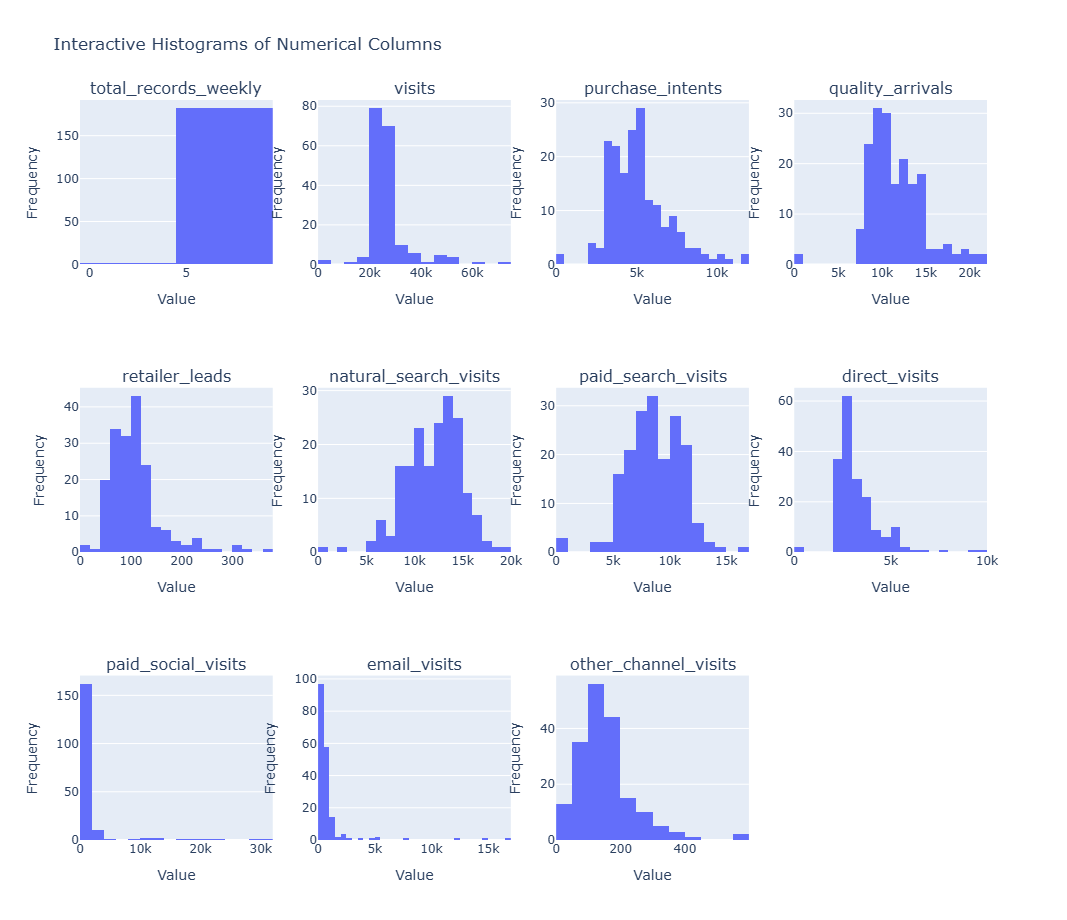

In [14]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math
golf_df = golf_df.sort_values(by='week_start', ascending=True)
#Identifying all numerical columns
numerical_cols = golf_df.select_dtypes(include=['number']).columns.tolist()
num_cols = len(numerical_cols)
print(f"Number of numerical columns: {num_cols}")

#Defining the grid dimensions (adjust rows/cols as needed, keeping 4x4 if possible)
rows = math.ceil(num_cols / 4)
cols = 4

# Creating the subplot figure
# Use specs=[[{'type':'xy'}, ...]] to define the type of plot for each cell
fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=numerical_cols
)

# Iterating through columns and adding interactive histograms
for i, col in enumerate(numerical_cols, 1):
    # Determining the row and column index for the subplot
    row_idx = math.ceil(i / cols)
    col_idx = (i - 1) % cols + 1

    # Creating a Plotly Express histogram for the single column
    # px.histogram automatically adds hover data/tooltips
    hist_fig = px.histogram(golf_df, x=col, nbins=15)

    # Adding the trace (the actual bars) to the main subplot figure
    for trace in hist_fig.data:
        fig.add_trace(
            go.Histogram(
                x=trace.x,
                marker_color=trace.marker.color,
                name=col, # Set the name for the hover tooltip legend
                hovertemplate='Value: %{x}<br>Count: %{y}<extra></extra>'
            ),
            row=row_idx,
            col=col_idx
        )

# Updating layout and display the interactive figure
fig.update_layout(
    title_text='Interactive Histograms of Numerical Columns',
    showlegend=False,
    height=300 * rows,  # Adjust height based on number of rows
    width=1200
)

# Updating axis labels slightly for aesthetics in subplots
fig.update_xaxes(title_text="Value")
fig.update_yaxes(title_text="Frequency")

fig.show()



In [15]:
# 1. Select only numeric columns to avoid string errors
golf_df_numeric = golf_df.select_dtypes(include=['number'])

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = golf_df_numeric.quantile(0.25)
Q3 = golf_df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

# Count outliers per column
outliers_count = ((golf_df_numeric < lower_bound) | (golf_df_numeric > upper_bound)).sum()
print(outliers_count)


total_records_weekly      2
visits                   14
purchase_intents          3
quality_arrivals          3
retailer_leads           10
natural_search_visits     1
paid_search_visits        2
direct_visits             8
paid_social_visits       15
email_visits             14
other_channel_visits      6
dtype: int64


In [16]:
# 3. Identify all outliers across the entire numeric dataframe
outlier_mask = (golf_df_numeric < lower_bound) | (golf_df_numeric > upper_bound)

# 4. Extract outliers and their corresponding week_start
# We "stack" the data to get a row for every outlier found
outliers_stacked = golf_df_numeric[outlier_mask].stack().reset_index()
outliers_stacked.columns = ['index', 'column_name', 'outlier_value']

# 5. Map the original week_start dates back using the index
outliers_stacked['week_start'] = outliers_stacked['index'].map(golf_df['week_start'])

# 6. Final Clean Table
final_outliers = outliers_stacked[['week_start', 'column_name', 'outlier_value']]

print("Outliers across all columns:")
print(final_outliers)


Outliers across all columns:
    week_start            column_name  outlier_value
0   2022-12-26   total_records_weekly            1.0
1   2022-12-26                 visits         2476.0
2   2022-12-26       quality_arrivals          962.0
3   2022-12-26     paid_search_visits           64.0
4   2022-12-26          direct_visits          271.0
..         ...                    ...            ...
73  2026-06-29                 visits          151.0
74  2026-06-29       quality_arrivals           92.0
75  2026-06-29  natural_search_visits           34.0
76  2026-06-29     paid_search_visits           74.0
77  2026-06-29          direct_visits           30.0

[78 rows x 3 columns]


In [11]:
final_outliers.style

,week_start,column_name,outlier_value
0,2022-12-26,total_records_weekly,1.000000
1,2022-12-26,visits,2476.000000
2,2022-12-26,quality_arrivals,962.000000
3,2022-12-26,paid_search_visits,64.000000
4,2022-12-26,direct_visits,271.000000
5,2023-01-02,paid_search_visits,480.000000
6,2023-03-20,email_visits,2085.000000
7,2023-05-08,email_visits,2054.000000
8,2023-08-21,email_visits,4875.000000
9,2023-08-28,email_visits,5018.000000


In [12]:
# Returns a Series where the index is the column names
column_means = golf_df.mean(numeric_only=True)
print(column_means)

total_records_weekly         6.937853
visits                   26750.355932
purchase_intents          5179.067797
quality_arrivals         11538.327684
retailer_leads              77.440678
natural_search_visits    12107.598870
paid_search_visits        8555.378531
direct_visits             3283.282486
paid_social_visits        1718.401130
email_visits               932.389831
other_channel_visits       153.316384
dtype: float64


In [13]:
outlier_dfv = final_outliers[final_outliers['column_name'] == 'visits']
#outlier_dfv 
sorted_df = outlier_dfv.sort_values(by='outlier_value', ascending=False)
sorted_df

,week_start,column_name,outlier_value
16,2024-04-29,visits,71005.0
25,2024-06-24,visits,63673.0
28,2024-07-01,visits,51535.0
52,2024-08-19,visits,51320.0
14,2024-04-22,visits,50499.0
48,2024-08-12,visits,50374.0
42,2024-08-05,visits,49947.0
10,2023-09-11,visits,48020.0
23,2024-06-17,visits,47548.0
32,2024-07-15,visits,45913.0


Our strategy of treating the outliers will be to convert them to NANs so that prophet will extrpolate values for them and reduce their effect on the forecast.

In [17]:
# 1. Access and clean the initial data safely
# (Assumes 'data' DataFrame already exists in your environment)
golf_df = data[data['model'] == 'Golf'].copy()
golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])
golf_df = golf_df.sort_values(by='week_start', ascending=True)
golf_df = golf_df.iloc[1:-1]

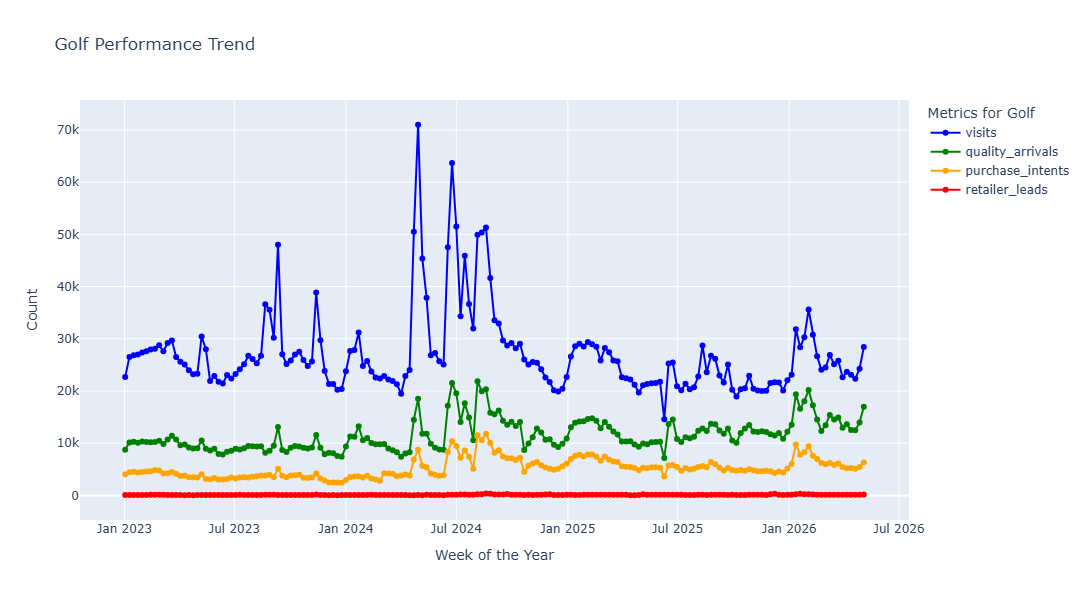

In [74]:
import plotly.express as px

# 1. Sort the DataFrame (ensure week_start is your x-axis)
golf_df_sorted = golf_df.sort_values(by='week_start', ascending=True)

# 2. Plot multiple columns by passing a list to 'y'
fig = px.line(
    golf_df_sorted,
    x='week_start',
    y=['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads'],  # List of columns
    title='Golf Performance Trend',
    markers=True,
    height=600,
    # Define custom colors for each column
    color_discrete_map={
        "visits": "blue",
        "quality_arrivals": "green",
        "purchase_intents": "orange",
        "retailer_leads": "red"
    }
)

# 3. Customizing labels and layout
fig.update_layout(
    xaxis_title='Week of the Year',
    yaxis_title='Count',
    legend_title='Metrics for Golf',
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True)
)

# 4. Display the figure
fig.show()


If you read this plot with respect to blue, green and yellow lines: all our showing almost same pattern across 3 years weekly data. I see upward spikes in all 3 KPIs starting from 15 april 2024 with blue values at apprx 24k spiking to 50K in 22 april 2024 and peaking at 71k on 29 April 2024. And came down on 6 May 2024 to 45K and then 37K on 13 May 2024 and finally 26K on 20 May 2024. The other KPIs QAs and PIs have shown exactly similar trend. This trend has repeated itself with lesser values at different years and different weeks. Looks like this is an outcome of an event. Our data range is from 22 Dec 2022 till 12 Jan 2026. This spikes in April, June and Aug in the year 2024 does not appear in the year 2023 and 2025. Also during Dec (Christmas time/Boxing day) or values have remained at apprx 20K (blue line) for week starting 25 Dec 2023 and again 20K for week starting 23 Dec 2024 and again apprx 20K for week starting 22 Dec 2025.   This can be seen from the above plot. The consistent behavior around Christmas confirms a stable annual pattern, while the absence of spikes in April, June, and August in 2023 and same periods in 2025 suggests those 2024 events were a one-off campaign or external shock, not a recurring holiday. Treat these 2024 events as one-off outliers . Or to set the y values for those specific dates to NaN in our DataFrame before training the model. Prophet will interpolate them and learn the underlying seasonal pattern without forcing a "holiday effect" where none exists in other years.

### Building Model 0a: Removing Outliers and running model on full data from 2 Jan 2023 to 12 Jan 2026.

In [18]:
golf = data[data['model'] == 'Golf']
golf['week_start'] = pd.to_datetime(golf['week_start'])
golf = golf.iloc[1:-1]

In [19]:
golf_df = data[data['model'] == 'Golf']
golf_df['week_start'] = pd.to_datetime(golf['week_start'])
golf_df = golf_df.iloc[1:-1]
golf_df = golf_df.sort_values(by='week_start', ascending=True)
golf_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 2052 to 1282
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   week_start             182 non-null    datetime64[ns]
 1   total_records_weekly   182 non-null    int64         
 2   model                  182 non-null    object        
 3   visits                 182 non-null    int64         
 4   purchase_intents       182 non-null    int64         
 5   quality_arrivals       182 non-null    int64         
 6   retailer_leads         182 non-null    int64         
 7   natural_search_visits  182 non-null    int64         
 8   paid_search_visits     182 non-null    int64         
 9   direct_visits          182 non-null    int64         
 10  paid_social_visits     182 non-null    int64         
 11  email_visits           182 non-null    int64         
 12  other_channel_visits   182 non-null    int64         
dtypes: dat

In [20]:
import pandas as pd
import numpy as np

# List of numeric KPI columns
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Create a copy to preserve original if needed
golf_df_cleaned = golf_df.copy()

for col in kpis:
    # 1. Calculate IQR bounds
    Q1 = golf_df_cleaned[col].quantile(0.25)
    Q3 = golf_df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 2 * IQR
    upper_bound = Q3 + 2 * IQR
    
    # 2. Mask values outside bounds with NaN
    # The mask() function replaces values where the condition is True
    golf_df_cleaned[col] = golf_df_cleaned[col].mask(
        (golf_df_cleaned[col] < lower_bound) | (golf_df_cleaned[col] > upper_bound), 
        np.nan
    )

# Result: golf_df_cleaned now has week_start AND numeric NaNs for outliers
print(golf_df_cleaned.tail())


     week_start  total_records_weekly model   visits  purchase_intents  \
211  2026-06-01                     7  Golf  26494.0            5690.0   
2079 2026-06-08                     7  Golf  23223.0            4942.0   
581  2026-06-15                     7  Golf  22297.0            4576.0   
721  2026-06-22                     7  Golf  21238.0            4259.0   
1282 2026-06-29                     1  Golf      NaN              31.0   

      quality_arrivals  retailer_leads  natural_search_visits  \
211            14844.0            87.0                   7352   
2079           12996.0           126.0                   6126   
581            12644.0           113.0                   5618   
721            11634.0            95.0                   5294   
1282               NaN             0.0                     34   

      paid_search_visits  direct_visits  paid_social_visits  email_visits  \
211                13098           3254                2152           106   
2079      

In [19]:
print((golf_df_cleaned == 0).sum())
golf_df_cleaned.isna().sum()

week_start                0
total_records_weekly      0
model                     0
visits                    0
purchase_intents          0
quality_arrivals          0
retailer_leads           58
natural_search_visits     0
paid_search_visits        0
direct_visits             0
paid_social_visits       53
email_visits              0
other_channel_visits      0
dtype: int64


week_start                0
total_records_weekly      0
model                     0
visits                   13
purchase_intents          2
quality_arrivals          2
retailer_leads            1
natural_search_visits     0
paid_search_visits        0
direct_visits             0
paid_social_visits        0
email_visits              0
other_channel_visits      0
dtype: int64

In [21]:
golf_df_cleaned['retailer_leads'] = golf_df_cleaned['retailer_leads'].replace(0, np.nan)

In [21]:
golf_df_cleaned.style

,week_start,total_records_weekly,model,visits,purchase_intents,quality_arrivals,retailer_leads,natural_search_visits,paid_search_visits,direct_visits,paid_social_visits,email_visits,other_channel_visits
1049,2022-12-26 00:00:00,1,Golf,nan,407.000000,nan,nan,2108,64,271,0,4,1
2034,2023-01-02 00:00:00,7,Golf,22705.000000,4074.000000,8733.000000,nan,19331,480,2336,0,170,67
1443,2023-01-09 00:00:00,7,Golf,26532.000000,4430.000000,10124.000000,nan,16165,7145,2507,0,121,107
2045,2023-01-16 00:00:00,7,Golf,26864.000000,4508.000000,10279.000000,nan,14849,8934,2539,0,136,123
2391,2023-01-23 00:00:00,7,Golf,26981.000000,4388.000000,10090.000000,nan,15062,9073,2658,0,92,92
2042,2023-01-30 00:00:00,7,Golf,27397.000000,4467.000000,10322.000000,nan,14937,9678,2656,0,99,137
1438,2023-02-06 00:00:00,7,Golf,27630.000000,4596.000000,10214.000000,nan,13959,10363,2683,0,533,81
2409,2023-02-13 00:00:00,7,Golf,27966.000000,4605.000000,10194.000000,nan,13969,10685,2485,0,727,130
2392,2023-02-20 00:00:00,7,Golf,28098.000000,4863.000000,10230.000000,nan,14215,10203,2591,0,706,178
2411,2023-02-27 00:00:00,7,Golf,28742.000000,4779.000000,10490.000000,nan,14945,9736,2587,0,860,125


In [23]:
# Running the prophet model again on cleaned data
golf_df = golf_df_cleaned.copy()
# Model 0: Simple Model with data with replacing outliers with NANs 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Data Preparation
golf_df['ds'] = pd.to_datetime(golf_df['week_start'])
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Apply Log Transformation (log(1+x)) for all KPIs
for kpi in kpis:
    golf_df[f'log_{kpi}'] = np.log1p(golf_df[kpi])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = []
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # Initialize Model with UK Holidays
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    
    # Fit on all available historical data (up to Jan 19, 2026)
    m.fit(golf_df[['ds', f'log_{kpi}']].rename(columns={f'log_{kpi}': 'y'}))
    
    # 3. Create a dataframe covering BOTH History and 3 Months Future
    # 'periods=12' for 3 months (16 weeks) forward from 19 Jan 2026
    full_timeline_df = m.make_future_dataframe(periods=48, freq='W-MON')
    
    # Generate Predictions for the entire period (Dec 2022 to May 2026)
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # 5. Calculate MAPE (on historical scale only)
    # Join historical actuals with the corresponding historical predictions
    performance_df = forecast.set_index('ds').join(golf_df.set_index('ds')[[kpi]], how='inner')
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
    mape_scores[kpi] = mape
    
    
    # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Formatting the output for Rivery/Export
    forecast = forecast.rename(columns={'ds': 'week_start'})
    golf_df['week_start'] = pd.to_datetime(golf_df['week_start'])
    # MERGE ACTUALS: Join the original KPI column from ID3_df
    # ID3_df must have 'week_start' and the KPI column (e.g., 'visits')
    forecast_with_actuals = forecast.merge(
        golf[['week_start', kpi]], 
        on='week_start', 
        how='left'
    )

   # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Select columns and rename the KPI column (e.g., 'visits') to 'actual'
    forecast_clean = forecast_with_actuals[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', kpi]].copy()
    forecast_clean = forecast_clean.rename(columns={kpi: 'actual'})
    forecast_clean['KPI'] = kpi
    final_forecasts.append(forecast_clean)

   # 5. Final Output DataFrame
final_output_df = pd.concat(final_forecasts, ignore_index=True)
# final_output_df = final_output_df[final_output_df['week_start'] >= '2026-01-19']

# 6. Output MAPE Results
#print("\n--- Model Performance (MAPE) ---")
#for kpi, score in mape_scores.items():
#    print(f"{kpi}: {score:.2f}%")


Processing model for: visits


18:35:58 - cmdstanpy - INFO - Chain [1] start processing
18:35:59 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: quality_arrivals


18:35:59 - cmdstanpy - INFO - Chain [1] start processing
18:35:59 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: purchase_intents


18:36:00 - cmdstanpy - INFO - Chain [1] start processing
18:36:00 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: retailer_leads


18:36:01 - cmdstanpy - INFO - Chain [1] start processing
18:36:01 - cmdstanpy - INFO - Chain [1] done processing


In [21]:



# Separate DataFrames for each KPI starting 19 Jan 2026a
golf_visits_forecast = final_output_df[final_output_df['KPI'] == 'visits'].copy()
golf_purchase_intents_forecast = final_output_df[final_output_df['KPI'] == 'purchase_intents'].copy()
golf_quality_arrivals_forecast = final_output_df[final_output_df['KPI'] == 'quality_arrivals'].copy()
golf_retailer_leads_forecast = final_output_df[final_output_df['KPI'] == 'retailer_leads'].copy()

# Optional: Remove the 'KPI' column for a clean output for each
golf_visits_forecast.drop(columns=['KPI'], inplace=True)
golf_purchase_intents_forecast.drop(columns=['KPI'], inplace=True)
golf_quality_arrivals_forecast.drop(columns=['KPI'], inplace=True)
golf_retailer_leads_forecast.drop(columns=['KPI'], inplace=True)

# Select relevant columns for final output/plotting
golf_visits_forecast = golf_visits_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_v = golf_visits_forecast.copy()
golf_purchase_intents_forecast = golf_purchase_intents_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_pi = golf_purchase_intents_forecast.copy()
golf_quality_arrivals_forecast = golf_quality_arrivals_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_qa = golf_quality_arrivals_forecast.copy()
golf_retailer_leads_forecast = golf_retailer_leads_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_rl = golf_retailer_leads_forecast.copy()

# 1. CLEANING 
forecast_v.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_v.columns
]
# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_v = forecast_v[target_cols].copy()

# 1a. CLEANING 
forecast_pi.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_pi.columns
]
# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_pi = forecast_pi[target_cols].copy()

# 1b. CLEANING 
forecast_qa.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_qa.columns
]

# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_qa = forecast_qa[target_cols].copy()

# 1c. CLEANING 
forecast_rl.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_rl.columns
]

# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_rl = forecast_rl[target_cols].copy()

import time

# 2. DATABASE OPERATIONS
try:
    conn = redshift_connector.connect(**conn_args)
    conn.autocommit = True 
    cursor = conn.cursor()

    cols_definition = "week_start TIMESTAMP, yhat FLOAT, yhat_lower FLOAT, yhat_upper FLOAT, actual FLOAT"

    # --- STEP 1: DROP, WAIT, AND CREATE TABLES ---
    tables = {
        "public.m_golf_Forecast_Visits": forecast_cleaned_v,
        "public.m_golf_Forecast_PIs": forecast_cleaned_pi,
        "public.m_golf_Forecast_QAs": forecast_cleaned_qa,
        "public.m_golf_Forecast_RLs": forecast_cleaned_rl
    }

    for table_name in tables.keys():
        cursor.execute(f"DROP TABLE IF EXISTS {table_name};")
        time.sleep(3) # Wait for Redshift catalog update
        cursor.execute(f"CREATE TABLE {table_name} ({cols_definition});")
        print(f"Table {table_name} created successfully.")
    
    conn.commit()

    # --- STEP 2: PREPARE AND INSERT DATA INDIVIDUALLY ---
    
    # A. Insert Visits
    print("Inserting data into golf_Forecast_Visits...")
    df_v = forecast_cleaned_v.where(pd.notna(forecast_cleaned_v), None)
    df_v['week_start'] = pd.to_datetime(df_v['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_v = [tuple(x) for x in df_v.to_numpy()]
    sql_v = f"INSERT INTO public.m_golf_Forecast_Visits (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_v, tuples_v)
    conn.commit()

    # B. Insert PIs
    print("Inserting data into golf_Forecast_PIs...")
    df_pi = forecast_cleaned_pi.where(pd.notna(forecast_cleaned_pi), None)
    df_pi['week_start'] = pd.to_datetime(df_pi['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_pi = [tuple(x) for x in df_pi.to_numpy()]
    sql_pi = f"INSERT INTO public.m_golf_Forecast_PIs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_pi, tuples_pi)
    conn.commit()

    # C. Insert QAs
    print("Inserting data into golf_Forecast_QAs...")
    df_qa = forecast_cleaned_qa.where(pd.notna(forecast_cleaned_qa), None)
    df_qa['week_start'] = pd.to_datetime(df_qa['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_qa = [tuple(x) for x in df_qa.to_numpy()]
    sql_qa = f"INSERT INTO public.m_golf_Forecast_QAs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_qa, tuples_qa)
    conn.commit()

    # C. Insert RLs
    print("Inserting data into golf_Forecast_RLs...")
    df_rl = forecast_cleaned_rl.where(pd.notna(forecast_cleaned_rl), None)
    df_rl['week_start'] = pd.to_datetime(df_rl['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_rl = [tuple(x) for x in df_rl.to_numpy()]
    sql_rl = f"INSERT INTO public.m_golf_Forecast_RLs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_rl, tuples_rl)
    conn.commit()

    print("Success: All 4 KPI forecasts pushed to Redshift.")

except Exception as e:
    print(f"Error occurred: {e}")
    raise 
finally:
    cursor.close()
    conn.close()
      


Table public.m_golf_Forecast_Visits created successfully.
Table public.m_golf_Forecast_PIs created successfully.
Table public.m_golf_Forecast_QAs created successfully.
Table public.m_golf_Forecast_RLs created successfully.
Inserting data into golf_Forecast_Visits...
Inserting data into golf_Forecast_PIs...
Inserting data into golf_Forecast_QAs...
Inserting data into golf_Forecast_RLs...
Success: All 4 KPI forecasts pushed to Redshift.


In [24]:
import pandas as pd
import holidays

# 1. Get UK bank holidays using the holidays package
# Note: The 'holidays' library is dynamic and provides correct dates, including substitute days.
uk_holidays = holidays.country_holidays('GB', years=range(2023, 2027))

# Convert the library output to a DataFrame suitable for Prophet
# We set a small window of 0 or 1 day for standard bank holidays
holidays_df = pd.DataFrame(list(uk_holidays.items()), columns=['ds', 'holiday'])
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])
holidays_df['lower_window'] = 0
holidays_df['upper_window'] = 1 # Effect likely limited to the day after

# 2. Add the specific, non-recurring 2024 events (One-Offs)
# These dates are specific to your website's data and are treated as unique historical anomalies.
one_off_events_2024 = pd.DataFrame([
    # April/May 2024 Event Window (1-day event with a large 10-day window to cover the multi-day spike)
    {'holiday': 'OneOff_AprMay_Event_2024', 'ds': pd.to_datetime('2024-04-29'), 'lower_window': -10, 'upper_window': 10},
    
    # June/July 2024 Event Window (1-day event with a large 10-day window)
    {'holiday': 'OneOff_JunJul_Event_2024', 'ds': pd.to_datetime('2024-06-24'), 'lower_window': -10, 'upper_window': 10},
])

# Concatenate all events and sort by date
holidays_df = pd.concat([holidays_df, one_off_events_2024]).sort_values('ds').reset_index(drop=True)

# Define columns as strings for Prophet
holidays_df['holiday'] = holidays_df['holiday'].astype(str)

print(holidays_df)


           ds                    holiday  lower_window  upper_window
0  2023-01-01             New Year's Day             0             1
1  2023-01-02  New Year's Day (observed)             0             1
2  2023-04-07                Good Friday             0             1
3  2023-05-01                    May Day             0             1
4  2023-05-08  Coronation of Charles III             0             1
5  2023-05-29        Spring Bank Holiday             0             1
6  2023-12-25              Christmas Day             0             1
7  2023-12-26                 Boxing Day             0             1
8  2024-01-01             New Year's Day             0             1
9  2024-03-29                Good Friday             0             1
10 2024-04-29   OneOff_AprMay_Event_2024           -10            10
11 2024-05-06                    May Day             0             1
12 2024-05-27        Spring Bank Holiday             0             1
13 2024-06-24   OneOff_JunJul_Even

In [25]:
# Model 1
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools
golf_df_sorted = golf_df.copy()
# 1. Prepare Data & Split
# Assuming df has columns: ['week_start', 'visits', 'purchase_intents', 'quality_arrivals']
golf_df_sorted ['ds'] = pd.to_datetime(golf_df_sorted ['week_start'])
kpis = ['visits', 'purchase_intents', 'quality_arrivals', 'retailer_leads']

for kpi in kpis:
    golf_df_sorted[f'log_{kpi}'] = np.log1p(golf_df_sorted[kpi])

# Define test size (3 months / 1 quarter = ~13 weeks)
split_date = golf_df_sorted ['ds'].max() - pd.DateOffset(months=3)
train_full = golf_df_sorted [golf_df_sorted ['ds'] <= split_date]
test_full = golf_df_sorted [golf_df_sorted ['ds'] > split_date]

# 2. Define Custom Holidays (Include all one-off events)
#holidays_df = pd.DataFrame({
#    'holiday': 'one_off_event',
#    'ds': pd.to_datetime(['2023-05-15', '2024-11-20', '2025-06-10']), # Example dates
#    'lower_window': 0,
#    'upper_window': 1,
#})

# 3. Grid Search Function
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0, 10.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

def tune_prophet(train_df, kpi):
    rmses = []
    # Rename KPI to 'y' for Prophet
    df_kpi = train_df[['ds', kpi]].rename(columns={kpi: 'y'})
    
    for params in all_params:
        m = Prophet(holidays=holidays_df, **params).fit(df_kpi)
        # Use cross-validation to find the best params on training data only
        df_cv = cross_validation(m, initial='730 days', period='90 days', horizon='90 days')
        df_p = performance_metrics(df_cv, rolling_window=1)
        rmses.append(df_p['rmse'].values[0])
        
    best_params = all_params[rmses.index(min(rmses))]
    return best_params

# 4. Final Model Execution
forecasts = {}
for kpi in kpis:
    print(f"Tuning and forecasting for: {kpi}...")
    
    # Get optimal params
    best_p = tune_prophet(train_full, kpi)
    
   
    # Train final model on full training set
    m = Prophet(holidays=holidays_df, **best_p)
    m.fit(train_full[['ds', kpi]].rename(columns={kpi: 'y'}))
    
    # Predict on test data dates
    future = test_full[['ds']]
    forecasts[kpi] = m.predict(future)

       # Accessing the parameters for each specific KPI
    print("Visits Params:", best_params_storage['visits'])
    print("Purchase Intent Params:", best_params_storage['purchase_intents'])
    print("Quality Arrival Params:", best_params_storage['quality_arrivals'])
    print("Retailer Leads Params:", best_params_storage['retailer_leads'])
 


Tuning and forecasting for: visits...


18:36:21 - cmdstanpy - INFO - Chain [1] start processing
18:36:22 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]18:36:22 - cmdstanpy - INFO - Chain [1] start processing
18:36:23 - cmdstanpy - INFO - Chain [1] done processing
18:36:23 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
18:36:23 - cmdstanpy - INFO - Chain [1] start processing
18:36:29 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:07<00:23,  7.74s/it]18:36:30 - cmdstanpy - INFO - Chain [1] start processing
18:36:30 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:08<00:07,  3.79s/it]18:36:31 - cmdstanpy - INFO - Chain

NameError: name 'best_params_storage' is not defined

In [ ]:
golf_df_sorted

## Model 1: Train-Test Split 3 months and test on unexposed data. Outlier treated with custom holidays included in holidays_df for April-June 2024 one off event. Auto Grid Search with cross-tab approach. Results:The MAPE for visits is: 11.58%. The MAPE for purchase_intents is: 13.66%. The MAPE for quality_arrivals is: 27.38%

In [17]:
import pandas as pd
import numpy as np
import itertools
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# 1. Data Preparation & Log Transformation
golf_df_sorted['ds'] = pd.to_datetime(golf_df_sorted['week_start'])
kpis = ['visits', 'purchase_intents', 'quality_arrivals']

# Apply Log Transformation (log(1+x)) to handle potential zeros safely
for kpi in kpis:
    golf_df_sorted[f'log_{kpi}'] = np.log1p(golf_df_sorted[kpi])

# Train-Test Split (Last 3 months for testing)
split_date = golf_df_sorted['ds'].max() - pd.DateOffset(months=3)
train_full = golf_df_sorted[golf_df_sorted['ds'] <= split_date]
test_full = golf_df_sorted[golf_df_sorted['ds'] > split_date]

# 2. Holidays: Custom Events + UK Bank Holidays
#holidays_df = pd.DataFrame({
#    'holiday': 'one_off_event',
#    'ds': pd.to_datetime(['2023-05-15', '2024-11-20', '2025-06-10']),
#    'lower_window': 0,
#    'upper_window': 1,
#})

# 3. Grid Search Setup
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0, 10.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

def tune_prophet(train_df, log_kpi_col):
    rmses = []
    df_kpi = train_df[['ds', log_kpi_col]].rename(columns={log_kpi_col: 'y'})
    
    for params in all_params:
        # Note: log transformation naturally models multiplicative effects, 
        # so seasonality_mode='additive' is typically best here
        m = Prophet(holidays=holidays_df, seasonality_mode='additive', **params)
        m.add_country_holidays(country_name='UK')
        m.fit(df_kpi)
        
        df_cv = cross_validation(m, initial='730 days', period='90 days', horizon='90 days')
        df_p = performance_metrics(df_cv, rolling_window=1)
        rmses.append(df_p['rmse'].values[0])
        
    return all_params[rmses.index(min(rmses))]

# 4. Iterative Execution & Inverse Transformation
forecasts = {}
best_params_storage = {}

for kpi in kpis:
    print(f"--- Processing {kpi} ---")
    log_col = f'log_{kpi}'
    
    # Grid Search on Training Data
    best_p = tune_prophet(train_full, log_col)
    best_params_storage[kpi] = best_p
    
    # Train Final Model
    m = Prophet(holidays=holidays_df, seasonality_mode='additive', **best_p)
    m.add_country_holidays(country_name='UK')
    m.fit(train_full[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Forecast
    future = test_full[['ds']]
    forecast_log = m.predict(future)
    
    # Inverse Transformation (e^y - 1)
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast_log[col] = np.expm1(forecast_log[col])
    
    forecasts[kpi] = forecast_log

# 5. Output Parameters & Performance
for kpi in kpis:
    print(f"\nBest Params for {kpi}: {best_params_storage[kpi]}")
    actuals = test_full[kpi].values
    preds = forecasts[kpi]['yhat'].values
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
    print(f"Final MAPE for {kpi}: {mape:.2f}%")


--- Processing visits ---


22:28:58 - cmdstanpy - INFO - Chain [1] start processing
22:28:58 - cmdstanpy - INFO - Chain [1] done processing
22:28:58 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:28:58 - cmdstanpy - INFO - Chain [1] start processing
22:29:01 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/3 [00:00<?, ?it/s]22:29:01 - cmdstanpy - INFO - Chain [1] start processing
22:29:01 - cmdstanpy - INFO - Chain [1] done processing
22:29:01 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:29:02 - cmdstanpy - INFO - Chain [1] start processing
22:29:03 - cmdstanpy - INFO - Chain [1] done processing
 33%|████████████████████████████                                                        | 1/3 [00:02<00:05,  2.52s/i

--- Processing purchase_intents ---


22:35:58 - cmdstanpy - INFO - Chain [1] start processing
22:35:58 - cmdstanpy - INFO - Chain [1] done processing
22:35:58 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:35:58 - cmdstanpy - INFO - Chain [1] start processing
22:36:00 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/3 [00:00<?, ?it/s]22:36:01 - cmdstanpy - INFO - Chain [1] start processing
22:36:01 - cmdstanpy - INFO - Chain [1] done processing
22:36:01 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:36:01 - cmdstanpy - INFO - Chain [1] start processing
22:36:05 - cmdstanpy - INFO - Chain [1] done processing
 33%|████████████████████████████                                                        | 1/3 [00:04<00:09,  4.56s/i

--- Processing quality_arrivals ---


22:42:55 - cmdstanpy - INFO - Chain [1] start processing
22:42:56 - cmdstanpy - INFO - Chain [1] done processing
22:42:56 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:42:56 - cmdstanpy - INFO - Chain [1] start processing
22:42:58 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/3 [00:00<?, ?it/s]22:42:58 - cmdstanpy - INFO - Chain [1] start processing
22:42:58 - cmdstanpy - INFO - Chain [1] done processing
22:42:58 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:42:59 - cmdstanpy - INFO - Chain [1] start processing
22:43:00 - cmdstanpy - INFO - Chain [1] done processing
 33%|████████████████████████████                                                        | 1/3 [00:02<00:05,  2.61s/i


Best Params for visits: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 10.0}
Final MAPE for visits: 15.22%

Best Params for purchase_intents: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 0.1}
Final MAPE for purchase_intents: 15.18%

Best Params for quality_arrivals: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.1, 'holidays_prior_scale': 0.1}
Final MAPE for quality_arrivals: 13.36%


In [18]:
preds

array([10514.08696101, 10328.10060349, 10663.47365773, 11354.07443335,
       11707.5619819 , 11140.71436263,  9976.15045959,  9076.76047663,
        8995.73505328,  9800.31153741, 11201.63167355, 12692.84087713,
       13818.38939505, 14367.31676984])

In [19]:
import pandas as pd

# List to store the simplified DataFrames for each KPI
final_tables = {}

for kpi in kpis:
    # Get the specific columns from the existing forecasts dictionary
    df_result = forecasts[kpi][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    
    # Rename 'ds' back to 'week_start' for your reporting
    df_result = df_result.rename(columns={'ds': 'week_start'})
    
    # Add a column to identify the KPI if you plan to merge them later
    df_result['kpi'] = kpi
    
    final_tables[kpi] = df_result

# Example: Display the head of the 'visits' results
print(final_tables['visits'].head(20))

# Optional: Merge all 3 into one large "Master Forecast" DataFrame
master_forecast_df = pd.concat(final_tables.values(), ignore_index=True)


   week_start          yhat    yhat_lower    yhat_upper     kpi
0  2025-10-20  19039.441630  16887.714526  21320.371872  visits
1  2025-10-27  18924.658477  16928.985659  21262.506847  visits
2  2025-11-03  19592.143731  17440.168190  22186.211521  visits
3  2025-11-10  20485.954043  18249.861375  23209.309402  visits
4  2025-11-17  20446.684130  18161.163507  23042.092253  visits
5  2025-11-24  18930.622413  16736.163566  21321.818418  visits
6  2025-12-01  16781.389034  14869.764077  19201.464728  visits
7  2025-12-08  15272.577173  13557.154762  17706.759671  visits
8  2025-12-15  15056.474258  13132.237797  17173.432848  visits
9  2025-12-22  16116.220705  14041.495682  18698.044733  visits
10 2025-12-29  18004.261597  15732.661478  21075.913714  visits
11 2026-01-05  20037.518621  17119.295984  23783.934680  visits
12 2026-01-12  21586.725636  18254.540971  25782.618377  visits
13 2026-01-19  22317.799974  18892.374248  26802.777830  visits


In [20]:
# Model 1
import numpy as np

mape_results = {}

for kpi in kpis:
    # Extract actuals from the test set and predictions from the forecast
    actuals = test_full[kpi].values
    predictions = forecasts[kpi]['yhat'].values
    
    # Calculate MAPE: mean of (|actual - predicted| / actual) * 100
    # Note: We add a tiny epsilon to denominator to avoid division by zero if necessary
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    mape_results[kpi] = mape

# Displaying the results
for kpi, score in mape_results.items():
    print(f"The MAPE for {kpi} is: {score:.2f}%")


The MAPE for visits is: 15.22%
The MAPE for purchase_intents is: 15.18%
The MAPE for quality_arrivals is: 13.36%


In [21]:
import pandas as pd
import numpy as np
from prophet import Prophet

# 1. Calculate how many weeks to forecast
last_date = golf_df_sorted['ds'].max()
target_start = pd.to_datetime('2026-01-12')
target_end = target_start + pd.DateOffset(months=3)

# Calculate weeks needed from last_date to cover the full next quarter
weeks_needed = (target_end - last_date).days // 7 + 1

future_forecasts = {}
best_params_storage = {} # Re-initializing to avoid KeyErrors

for kpi in kpis:
    print(f"--- Forecasting Future 2026 for {kpi} ---")
    log_col = f'log_{kpi}'
    
    # 2. Fit Model on ALL historical data (Full Train + Previous Test)
    # We use the parameters from your previous grid search
    m_final = Prophet(holidays=holidays_df, seasonality_mode='additive', **best_p) # Using latest best_p
    m_final.add_country_holidays(country_name='UK')
    m_final.fit(golf_df_sorted[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # 3. Create Future Dataframe
    # periods must be large enough to reach past Jan 26
    full_future = m_final.make_future_dataframe(periods=weeks_needed, freq='W-MON')
    
    # Filter ONLY for the new forecast period (from Jan 26, 2026 onwards)
    new_forecast_period = full_future[full_future['ds'] >= target_start].copy()
    
    if new_forecast_period.empty:
        print(f"Warning: No dates found after {target_start}. Check your dataset's last date: {last_date}")
        continue
        
    # 4. Predict
    forecast_log = m_final.predict(new_forecast_period)
    
    # 5. Inverse Transformation
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast_log[col] = np.expm1(forecast_log[col])
    
    # Rename columns and store
    forecast_log = forecast_log.rename(columns={'ds': 'week_start'})
    future_forecasts[kpi] = forecast_log[['week_start', 'yhat', 'yhat_lower', 'yhat_upper']]

# Display first few rows of the new forecast starting Jan 26, 2026
if 'visits' in future_forecasts:
    print(future_forecasts['visits'].head())


--- Forecasting Future 2026 for visits ---


22:52:28 - cmdstanpy - INFO - Chain [1] start processing
22:52:29 - cmdstanpy - INFO - Chain [1] done processing


--- Forecasting Future 2026 for purchase_intents ---


22:52:29 - cmdstanpy - INFO - Chain [1] start processing
22:52:30 - cmdstanpy - INFO - Chain [1] done processing


--- Forecasting Future 2026 for quality_arrivals ---


22:52:31 - cmdstanpy - INFO - Chain [1] start processing
22:52:31 - cmdstanpy - INFO - Chain [1] done processing


  week_start          yhat    yhat_lower    yhat_upper
0 2026-01-12  27621.068097  24807.405293  30739.915392
1 2026-01-19  28904.723898  26136.259250  32488.824448
2 2026-01-26  28821.200021  25815.411401  32443.682223
3 2026-02-02  28118.611272  25247.321834  31448.939462
4 2026-02-09  27649.237682  24777.715294  30991.359791


In [22]:
future_forecasts['visits'].head(13)

,week_start,yhat,yhat_lower,yhat_upper
0,2026-01-12,27621.068097,24807.405293,30739.915392
1,2026-01-19,28904.723898,26136.259250,32488.824448
2,2026-01-26,28821.200021,25815.411401,32443.682223
3,2026-02-02,28118.611272,25247.321834,31448.939462
4,2026-02-09,27649.237682,24777.715294,30991.359791
5,2026-02-16,27697.978989,24717.377997,31286.113324
6,2026-02-23,27942.839334,24790.773001,31435.568928
7,2026-03-02,27906.438805,24710.394698,31882.370840
8,2026-03-09,27456.162967,24040.070019,31700.181818
9,2026-03-16,26810.194753,23287.550671,31612.661764


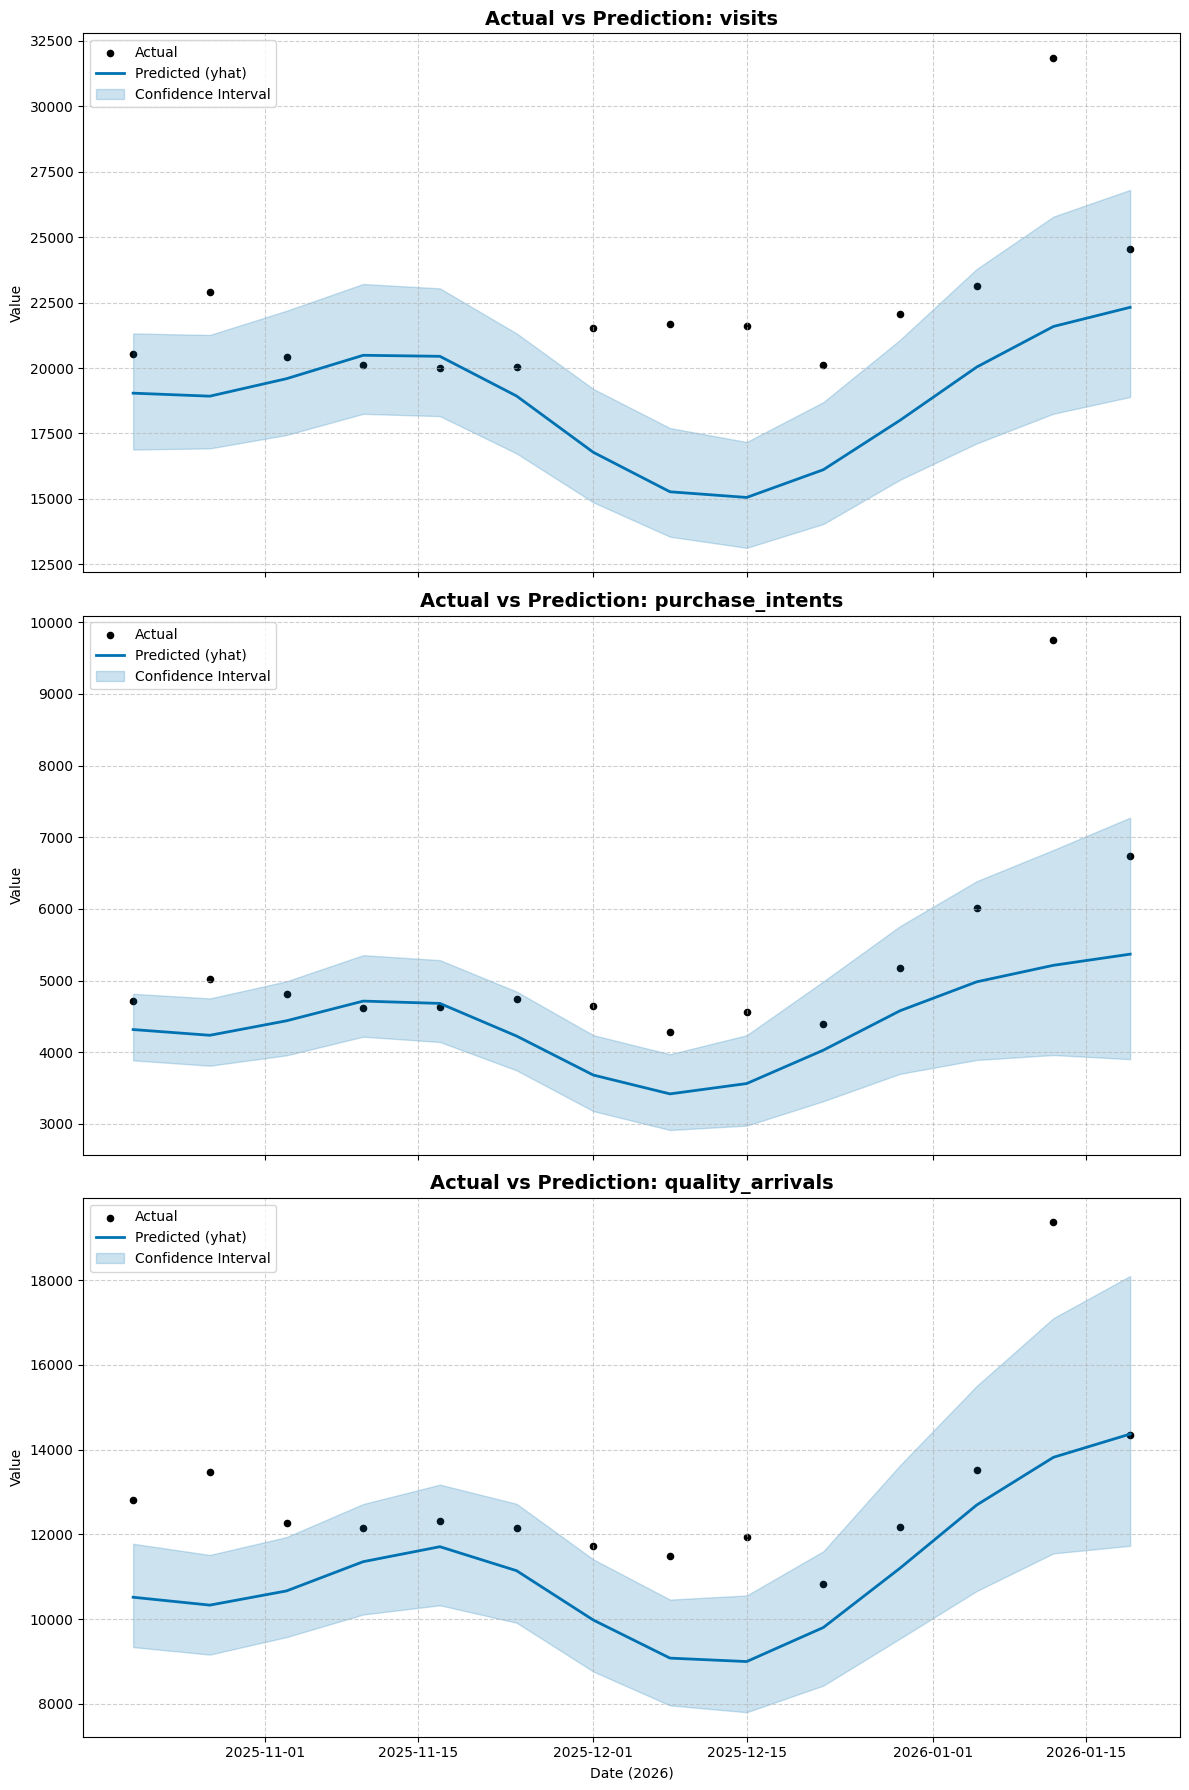

In [23]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots (one for each KPI)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18), sharex=True)

for i, kpi in enumerate(kpis):
    ax = axes[i]
    
    # Plot Actual Values from your test set
    ax.scatter(test_full['ds'], test_full[kpi], color='black', label='Actual', s=20)
    
    # Plot Predicted Values
    ax.plot(final_tables[kpi]['week_start'], final_tables[kpi]['yhat'], 
            color='#0072B2', label='Predicted (yhat)', linewidth=2)
    
    # Plot Confidence Intervals (Shaded Area)
    ax.fill_between(final_tables[kpi]['week_start'], 
                    final_tables[kpi]['yhat_lower'], 
                    final_tables[kpi]['yhat_upper'], 
                    color='#0072B2', alpha=0.2, label='Confidence Interval')
    
    # Formatting
    ax.set_title(f'Actual vs Prediction: {kpi}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Value')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Date (2026)')
plt.tight_layout()
plt.show()


22:53:50 - cmdstanpy - INFO - Chain [1] start processing
22:53:51 - cmdstanpy - INFO - Chain [1] done processing
22:53:51 - cmdstanpy - INFO - Chain [1] start processing
22:53:52 - cmdstanpy - INFO - Chain [1] done processing
22:53:53 - cmdstanpy - INFO - Chain [1] start processing
22:53:53 - cmdstanpy - INFO - Chain [1] done processing


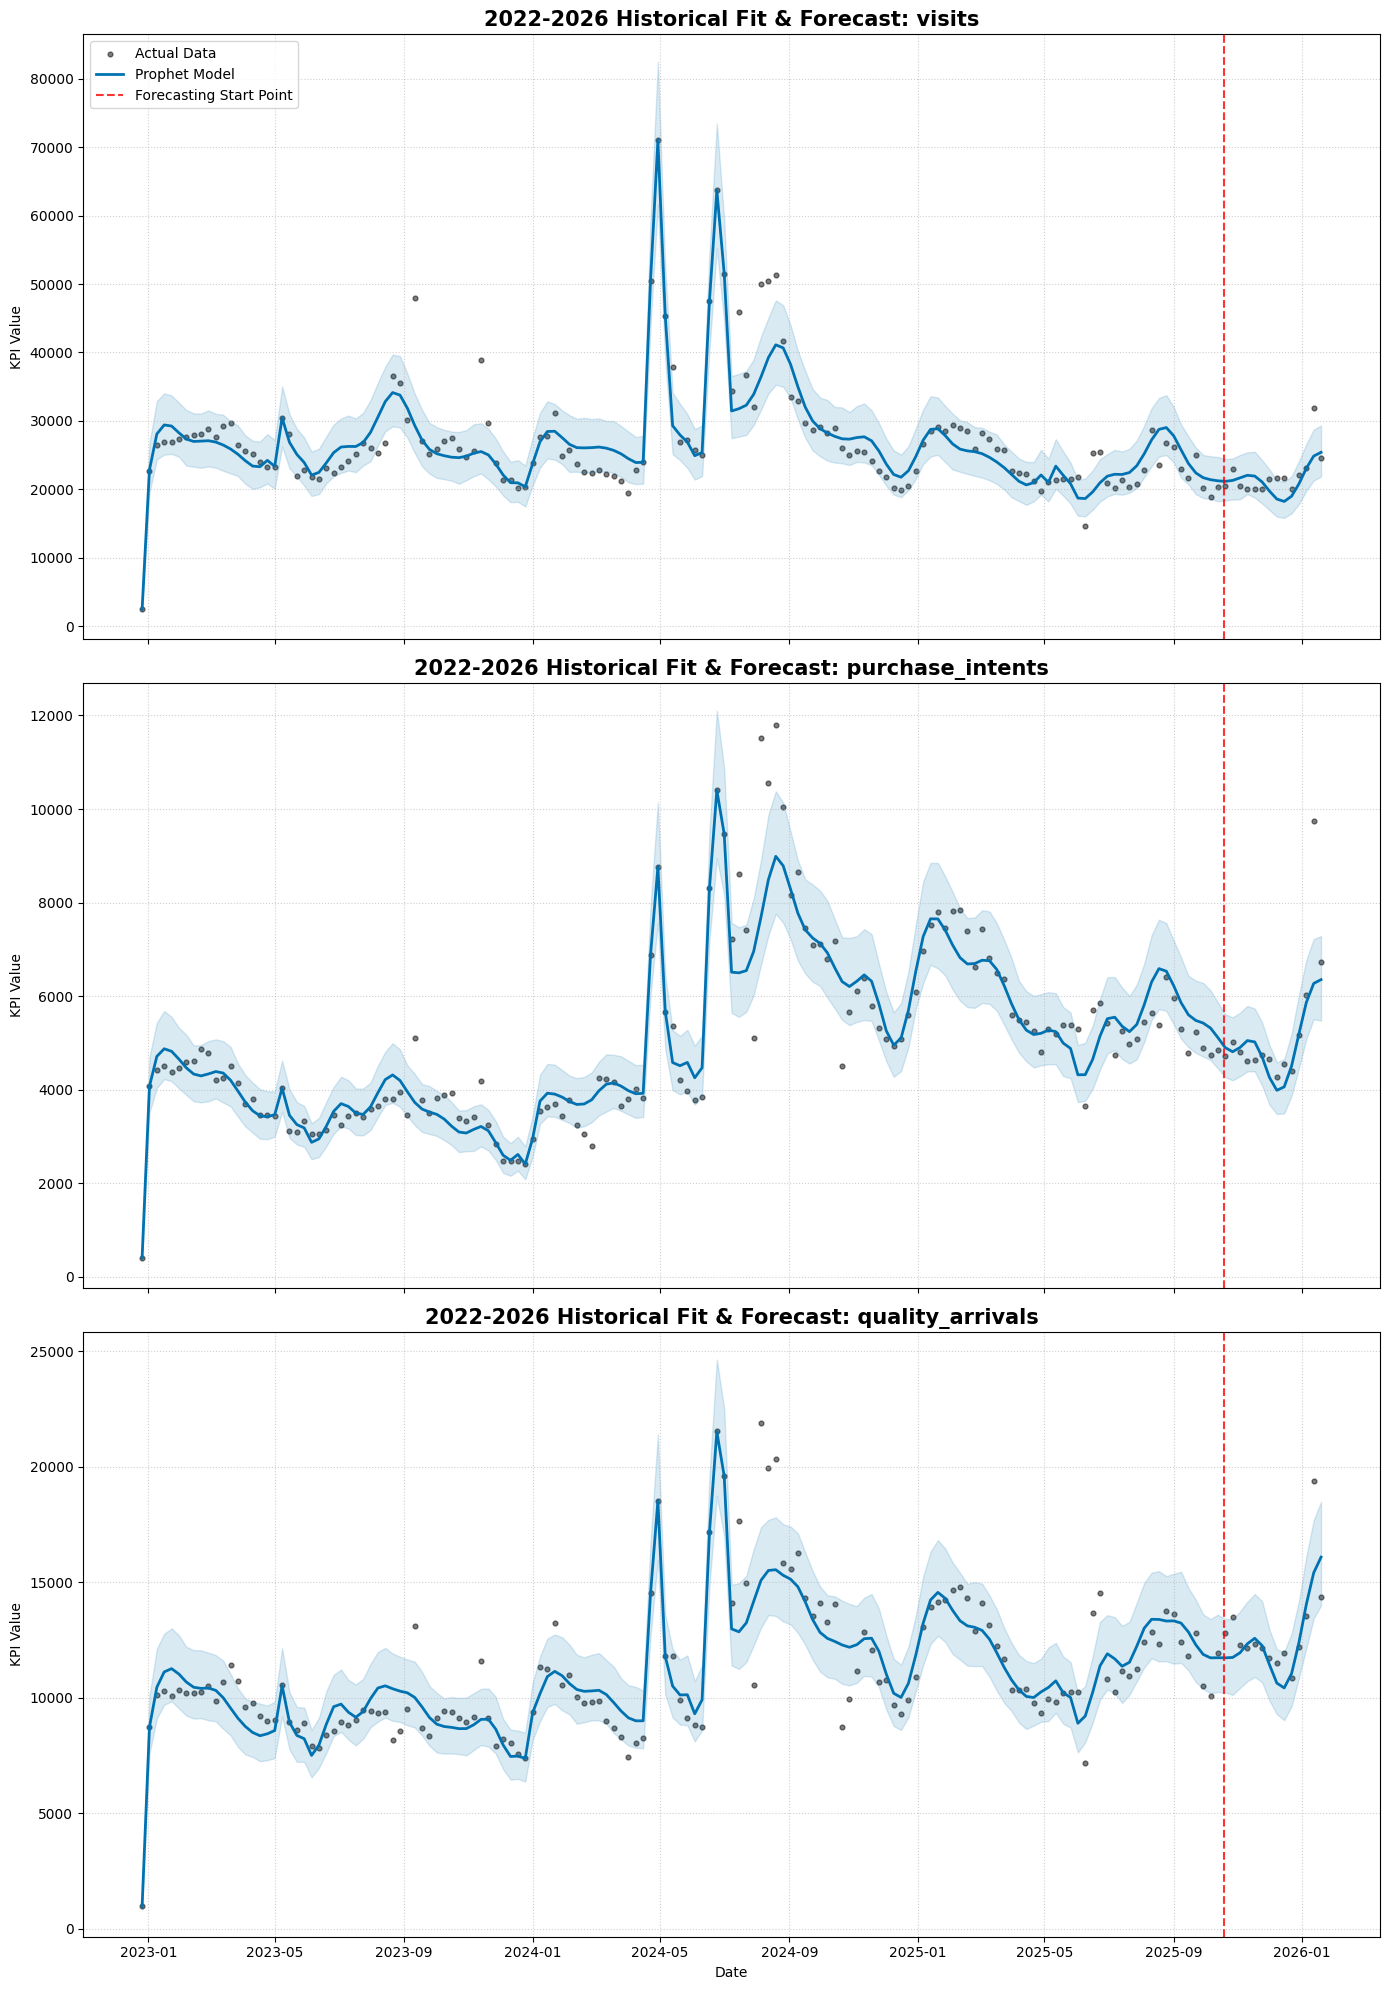

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from prophet import Prophet

# 1. Combine training and test for a continuous actuals line
full_actuals = pd.concat([train_full, test_full]).sort_values('ds')

# 2. Ensure best_params_storage is available
# If grid search wasn't saved, this provides standard stable defaults
if 'best_params_storage' not in locals() or not best_params_storage:
    print("Warning: best_params_storage not found. Using default stable parameters.")
    best_params_storage = {k: {'changepoint_prior_scale': 0.05, 
                               'seasonality_prior_scale': 10.0, 
                               'holidays_prior_scale': 10.0} for k in kpis}

# 3. Setup Plot
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 20), sharex=True)

for i, kpi in enumerate(kpis):
    ax = axes[i]
    log_col = f'log_{kpi}'
    
    # Re-train model on full history to get the best historical fit
    m_full = Prophet(holidays=holidays_df, seasonality_mode='additive', **best_params_storage[kpi])
    m_full.add_country_holidays(country_name='UK')
    m_full.fit(full_actuals[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Predict for the entire range
    forecast_full = m_full.predict(full_actuals[['ds']])
    
    # Inverse Transform predictions back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast_full[col] = np.expm1(forecast_full[col])
    
    # --- Plotting ---
    # Actuals (Dots)
    ax.scatter(full_actuals['ds'], full_actuals[kpi], color='black', label='Actual Data', s=12, alpha=0.5)
    
    # Model (Blue Line)
    ax.plot(forecast_full['ds'], forecast_full['yhat'], color='#0072B2', label='Prophet Model', linewidth=2)
    
    # Uncertainty (Shaded)
    ax.fill_between(forecast_full['ds'], forecast_full['yhat_lower'], forecast_full['yhat_upper'], 
                    color='#0072B2', alpha=0.15)
    
    # Split Marker (Vertical Red Line)
    ax.axvline(x=split_date, color='red', linestyle='--', alpha=0.8, label='Forecasting Start Point')
    
    # Formatting
    ax.set_title(f'2022-2026 Historical Fit & Forecast: {kpi}', fontsize=15, fontweight='bold')
    ax.set_ylabel('KPI Value')
    ax.grid(True, linestyle=':', alpha=0.6)
    if i == 0: ax.legend(loc='upper left')

plt.xlabel('Date')
plt.tight_layout()
plt.show()


The above plots tell us:
Model Fit: How closely the blue line follows the black dots from late 2022 through 2025.
Seasonality: If the model successfully captured the quarterly "swings".
The "Gap": The red dashed line marks the point where the model moved from "fitting" (Training) to "predicting" (Test).
Log-Scaling Effect: By plotting in the original scale, one can visually confirm if the log-transformation successfully handled high-volume spikes without creating negative values.

In [101]:
import pandas as pd
import numpy as np
from prophet import Prophet

# 1. Prepare Full Data (No Split)
# Ensure dates and log transforms are applied to the entire dataset
golf_df_sorted['ds'] = pd.to_datetime(golf_df_sorted['week_start'])
kpis = ['visits', 'purchase_intents', 'quality_arrivals']

for kpi in kpis:
    golf_df_sorted[f'log_{kpi}'] = np.log1p(golf_df_sorted[kpi])

# 2. Setup Future Dates (Next 4 Months)
# freq='W-MON' assumes your weeks start on Monday. 18 weeks approx. 4 months.
last_date = golf_df_sorted['ds'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1), 
                             periods=18, 
                             freq='W-MON')
future_df = pd.DataFrame({'ds': future_dates})

# 3. Execution Loop
future_forecasts = {}

for kpi in kpis:
    print(f"Training final model for: {kpi}...")
    log_col = f'log_{kpi}'
    
    # Use best_params_storage if it exists in your session, else use stable defaults
    params = best_params_storage.get(kpi, {'changepoint_prior_scale': 0.05, 
                                           'seasonality_prior_scale': 10.0, 
                                           'holidays_prior_scale': 10.0})
    
    # Initialize and fit on ALL available data
    m_final = Prophet(holidays=holidays_df, seasonality_mode='additive', **params)
    m_final.add_country_holidays(country_name='UK')
    m_final.fit(golf_df_sorted[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Predict for the next 4 months
    forecast = m_final.predict(future_df)
    
    # Inverse Transformation (Back to original scale)
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # Store only relevant columns
    forecast = forecast.rename(columns={'ds': 'week_start'})
    future_forecasts[kpi] = forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper']]

# 4. Generate Output DataFrame
# Combine all 3 KPIs into one clean table for export
output_list = []
for kpi in kpis:
    temp_df = future_forecasts[kpi].copy()
    temp_df['KPI'] = kpi
    output_list.append(temp_df)

final_2026_forecast_df = pd.concat(output_list, ignore_index=True)

# 5. Display/Export
print("\n--- Next 4 Months Forecast (Starting February 2026) ---")
print(final_2026_forecast_df.head(15))

# Export to CSV if needed
# final_2026_forecast_df.to_csv('golf_kpi_forecast_2026.csv', index=False)


Training final model for: visits...


13:44:40 - cmdstanpy - INFO - Chain [1] start processing
13:44:41 - cmdstanpy - INFO - Chain [1] done processing


Training final model for: purchase_intents...


13:44:41 - cmdstanpy - INFO - Chain [1] start processing
13:44:41 - cmdstanpy - INFO - Chain [1] done processing


Training final model for: quality_arrivals...


13:44:42 - cmdstanpy - INFO - Chain [1] start processing
13:44:43 - cmdstanpy - INFO - Chain [1] done processing



--- Next 4 Months Forecast (Starting February 2026) ---
   week_start          yhat    yhat_lower    yhat_upper     KPI
0  2026-01-26  23834.503287  19804.132249  29126.859008  visits
1  2026-02-02  23376.384057  19090.290404  28370.827528  visits
2  2026-02-09  23200.688241  19183.130993  28457.226942  visits
3  2026-02-16  23037.544534  18739.112420  28273.258064  visits
4  2026-02-23  22735.271115  18677.909017  27896.165737  visits
5  2026-03-02  22529.567371  18470.117657  27819.935013  visits
6  2026-03-09  22625.205158  18984.794689  27860.975604  visits
7  2026-03-16  22672.518243  18340.913732  27388.172465  visits
8  2026-03-23  21984.145010  18368.861580  26485.416920  visits
9  2026-03-30  20565.756216  16804.644642  25641.116290  visits
10 2026-04-06  19573.015685  16066.296540  23851.302285  visits
11 2026-04-13  20444.417610  16706.302809  25154.562814  visits
12 2026-04-20  23925.563217  19414.548714  29278.292260  visits
13 2026-04-27  28941.379380  23714.599337  3516

In [ ]:
Key Changes for this Implementation:
No Train-Test Split: The m_final.fit() call uses golf_df_sorted, ensuring the model learns from the most recent trends up to January 2026.
Extended Horizon: periods=18 with freq='W-MON' generates a forecast window into May 2026.
UK Holidays: Automatically includes the 2026 UK Bank Holiday calendar (Easter, May bank holidays) which significantly impact golf KPIs.
To Plot these specific results:
Use the same plotting script as before, but pass final_2026_forecast_df to the X-axis. Since there is no "Actual" data for the next 4 months, one will see the blue line extending into the "future" white space of the graph.

In [26]:
# BEST SELECTED: This approach uses best params for previous run achieved by train- test (3 month) approach but this approach uses full data for training and no test sata.
import pandas as pd
import numpy as np
from prophet import Prophet

# 1. Prepare Full Data (No Split)
golf_df_sorted['ds'] = pd.to_datetime(golf_df_sorted['week_start'])
kpis = ['visits', 'purchase_intents', 'quality_arrivals']

for kpi in kpis:
    golf_df_sorted[f'log_{kpi}'] = np.log1p(golf_df_sorted[kpi])

# 2. Setup Explicit Future Dates starting 19 Jan 2026
# periods=18 covers approx 4 months (18 weeks)
future_df = pd.DataFrame({
    'ds': pd.date_range(start='2026-01-19', periods=18, freq='W-MON')
})

# NEW: Explicitly define your Grid Search Optimized Parameters
optimized_params = {
    'visits': {
        'changepoint_prior_scale': 0.1, 
        'seasonality_prior_scale': 1.0, 
        'holidays_prior_scale': 10.0
    },
    'purchase_intents': {
        'changepoint_prior_scale': 0.5, 
        'seasonality_prior_scale': 0.01, 
        'holidays_prior_scale': 0.1
    },
    'quality_arrivals': {
        'changepoint_prior_scale': 0.5, 
        'seasonality_prior_scale': 0.1, 
        'holidays_prior_scale': 0.1
    }
}

# 3. Model Training & Forecast Loop
future_forecasts = {}

for kpi in kpis:
    print(f"Final training for {kpi}...")
    log_col = f'log_{kpi}'
    
    # Access best_params_storage from your previous session
    params = optimized_params[kpi]
    
    # Initialize and fit on ALL available data
    m_final = Prophet(holidays=holidays_df, seasonality_mode='additive', **params)
    m_final.add_country_holidays(country_name='UK')
    m_final.fit(golf_df_sorted[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Generate the prediction for the explicit 19 Jan 2026 start date
    forecast = m_final.predict(future_df)
    
    # Inverse Transform (e^y - 1)
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    forecast = forecast.rename(columns={'ds': 'week_start'})
    future_forecasts[kpi] = forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper']]

# 4. Consolidate Output
final_output = pd.concat([
    future_forecasts[k].assign(KPI=k) for k in kpis
], ignore_index=True)

# Verification: Display the first 5 rows to confirm the Jan 19 start
print(final_output[final_output['KPI'] == 'visits'].head())


Final training for visits...


23:10:51 - cmdstanpy - INFO - Chain [1] start processing
23:10:51 - cmdstanpy - INFO - Chain [1] done processing


Final training for purchase_intents...


23:10:52 - cmdstanpy - INFO - Chain [1] start processing
23:10:53 - cmdstanpy - INFO - Chain [1] done processing


Final training for quality_arrivals...


23:10:54 - cmdstanpy - INFO - Chain [1] start processing
23:10:55 - cmdstanpy - INFO - Chain [1] done processing


  week_start          yhat    yhat_lower    yhat_upper     KPI
0 2026-01-19  27600.105511  24633.523331  30953.160899  visits
1 2026-01-26  27360.842005  24603.949752  30585.718004  visits
2 2026-02-02  26613.195377  23678.464477  29971.700700  visits
3 2026-02-09  26110.261902  23348.140836  29237.790216  visits
4 2026-02-16  26095.324726  22982.097435  29603.265371  visits


In [28]:
# Define the new optimized parameters manually
optimized_params = {
    'visits': {
        'changepoint_prior_scale': 0.1, 
        'seasonality_prior_scale': 1.0, 
        'holidays_prior_scale': 10.0
    },
    'purchase_intents': {
        'changepoint_prior_scale': 0.5, 
        'seasonality_prior_scale': 0.01, 
        'holidays_prior_scale': 0.1
    },
    'quality_arrivals': {
        'changepoint_prior_scale': 0.5, 
        'seasonality_prior_scale': 0.1, 
        'holidays_prior_scale': 0.1
    }
}

print("--- Parameters Used for 2026 Forecast ---")

# Iterate through the KPIs using the new optimized_params dictionary
for kpi in ['visits', 'purchase_intents', 'quality_arrivals']:
    if kpi in optimized_params:
        params = optimized_params[kpi]
        print(f"\nKPI: {kpi.upper()}")
        print(f"  - Changepoint Prior Scale: {params['changepoint_prior_scale']}")
        print(f"  - Seasonality Prior Scale: {params['seasonality_prior_scale']}")
        print(f"  - Holidays Prior Scale:    {params['holidays_prior_scale']}")
    else:
        print(f"\nKPI: {kpi} - No parameters found in optimized_params.")


--- Parameters Used for 2026 Forecast ---

KPI: VISITS
  - Changepoint Prior Scale: 0.1
  - Seasonality Prior Scale: 1.0
  - Holidays Prior Scale:    10.0

KPI: PURCHASE_INTENTS
  - Changepoint Prior Scale: 0.5
  - Seasonality Prior Scale: 0.01
  - Holidays Prior Scale:    0.1

KPI: QUALITY_ARRIVALS
  - Changepoint Prior Scale: 0.5
  - Seasonality Prior Scale: 0.1
  - Holidays Prior Scale:    0.1


In [29]:
import numpy as np

# 1. Define MAPE function
def calculate_mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    # Avoid division by zero by filtering out actuals that are 0
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

mape_results = {}

# 2. Iterate through KPIs to calculate in-sample MAPE
for kpi in kpis:
    print(f"Calculating MAPE for {kpi}...")
    log_col = f'log_{kpi}'
    
    # Re-initialize the model with the BEST params for THIS KPI
    params = best_params_storage.get(kpi, {
        'changepoint_prior_scale': 0.05, 
        'seasonality_prior_scale': 10.0, 
        'holidays_prior_scale': 10.0
    })
    
    m_eval = Prophet(holidays=holidays_df, seasonality_mode='additive', **params)
    m_eval.add_country_holidays(country_name='UK')
    
    # Fit on all historical data
    m_eval.fit(golf_df_sorted[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Predict ONLY on historical dates (In-sample)
    in_sample_forecast = m_eval.predict(golf_df_sorted[['ds']])
    
    # Inverse Transform: Revert log1p using expm1 for BOTH predicted and actuals if needed
    # Predicted values are in 'yhat', actuals are in the original golf_df_sorted[kpi]
    y_pred_original = np.expm1(in_sample_forecast['yhat'])
    y_actual_original = golf_df_sorted[kpi].values
    
    # Calculate MAPE
    mape = calculate_mape(y_actual_original, y_pred_original)
    mape_results[kpi] = mape

# 3. Print Results
print("\n--- Model Performance (In-Sample MAPE) ---")
for kpi, score in mape_results.items():
    print(f"{kpi}: {score:.2f}%")


Calculating MAPE for visits...


23:15:30 - cmdstanpy - INFO - Chain [1] start processing
23:15:30 - cmdstanpy - INFO - Chain [1] done processing


Calculating MAPE for purchase_intents...


23:15:31 - cmdstanpy - INFO - Chain [1] start processing
23:15:31 - cmdstanpy - INFO - Chain [1] done processing


Calculating MAPE for quality_arrivals...


23:15:32 - cmdstanpy - INFO - Chain [1] start processing
23:15:33 - cmdstanpy - INFO - Chain [1] done processing



--- Model Performance (In-Sample MAPE) ---
visits: 8.09%
purchase_intents: 7.55%
quality_arrivals: 7.85%


In [30]:
golf_df_sorted = golf_df.sort_values(by='week_start', ascending=True)
golf_df_sorted

,week_start,total_records_weekly,model,visits,purchase_intents,quality_arrivals,retailer_leads,natural_search_visits,paid_search_visits,direct_visits,paid_social_visits,email_visits,other_channel_visits
89,2022-12-26,1,Golf,2476,407,962,0,2108,64,271,0,4,1
317,2023-01-02,7,Golf,22705,4074,8733,322,19331,480,2336,0,170,67
309,2023-01-09,7,Golf,26532,4430,10124,253,16165,7145,2507,0,121,107
816,2023-01-16,7,Golf,26864,4508,10279,253,14849,8934,2539,0,136,123
681,2023-01-23,7,Golf,26981,4388,10090,280,15062,9073,2658,0,92,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,2025-12-22,7,Golf,20119,4396,10829,299,6219,10818,2036,823,80,56
161,2025-12-29,8,Golf,22055,5177,12173,576,8538,9913,2492,823,97,82
279,2026-01-05,7,Golf,23125,6018,13514,692,10221,8159,2834,1277,211,159
911,2026-01-12,7,Golf,31846,9753,19369,1039,14259,10006,3890,1889,1277,229


## Auto Grid Search on Full Data till 19th Jan 2026

In [31]:
#Refreshed model for grid search on full data till 19 Jan 2026
import pandas as pd
import numpy as np
import itertools
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# 1. Data Preparation (Full Dataset)
# Ensure data ends at the week of 5 Jan 2026
golf_df_sorted['ds'] = pd.to_datetime(golf_df_sorted['week_start'])
golf_df_full = golf_df_sorted[golf_df_sorted['ds'] <= '2026-01-19'].copy()
kpis = ['visits', 'purchase_intents', 'quality_arrivals']

# Apply log transformation for stability in business metrics
for kpi in kpis:
    golf_df_full[f'log_{kpi}'] = np.log1p(golf_df_full[kpi])

# 2. Custom One-off Events + UK Bank Holidays
#holidays_df = pd.DataFrame({
#    'holiday': 'one_off_event',
#    'ds': pd.to_datetime(['2023-05-15', '2024-11-20', '2025-06-10']),
#    'lower_window': 0,
#    'upper_window': 1,
#})

# 3. Grid Search Setup for Hyperparameter Tuning
param_grid = {  
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.1, 1.0, 10.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]

def perform_grid_search(df, log_kpi_col):
    rmses = []
    df_tuning = df[['ds', log_kpi_col]].rename(columns={log_kpi_col: 'y'})
    
    for params in all_params:
        m = Prophet(holidays=holidays_df, seasonality_mode='additive', **params)
        m.add_country_holidays(country_name='UK')
        m.fit(df_tuning)
        
        # Cross-validation uses the history to simulate forecasting performance
        # initial: training window, horizon: forecast window to test
        df_cv = cross_validation(m, initial='730 days', period='90 days', horizon='90 days')
        df_p = performance_metrics(df_cv, rolling_window=1)
        rmses.append(df_p['rmse'].values[0])
        
    return all_params[rmses.index(min(rmses))]

# 4. Iterative Model Training and 16-Week Forecast
best_params_results = {}
final_forecast_list = []

# Define the explicit 16-week forecast period starting Jan 19, 2026
future_df_dates = pd.DataFrame({
    'ds': pd.date_range(start='2026-01-19', periods=16, freq='W-MON')
})

for kpi in kpis:
    print(f"Running grid search for: {kpi}...")
    log_col = f'log_{kpi}'
    
    # Identify best params using full available history
    best_p = perform_grid_search(golf_df_full, log_col)
    best_params_results[kpi] = best_p
    
    # Train the final model with best params on the full history
    m_final = Prophet(holidays=holidays_df, seasonality_mode='additive', **best_p)
    m_final.add_country_holidays(country_name='UK')
    m_final.fit(golf_df_full[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Predict 16 weeks forward
    forecast = m_final.predict(future_df_dates)
    
    # Inverse transform results (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # Formatting the output
    forecast = forecast.rename(columns={'ds': 'week_start'})
    forecast_clean = forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    forecast_clean['KPI'] = kpi
    final_forecast_list.append(forecast_clean)

# 5. Output Results
print("\n--- OPTIMAL HYPERPARAMETERS FOUND ---")
for kpi, params in best_params_results.items():
    print(f"{kpi}: {params}")

# Final Combined Forecast DataFrame
final_output_df = pd.concat(final_forecast_list, ignore_index=True)
print("\n--- 16-WEEK FORECAST (Starting 19 Jan 2026) ---")
print(final_output_df.head(20))


Running grid search for: visits...


23:19:59 - cmdstanpy - INFO - Chain [1] start processing
23:20:00 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]23:20:00 - cmdstanpy - INFO - Chain [1] start processing
23:20:01 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:01<00:03,  1.06s/it]23:20:01 - cmdstanpy - INFO - Chain [1] start processing
23:20:02 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:02<00:02,  1.06s/it]23:20:02 - cmdstanpy - INFO - Chain [1] start processing
23:20:03 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:03<00:01,  1.03s/it]23:20:03 - cmdstanpy - INFO - Chain [1] start processing
23:20:04 - cmds

Running grid search for: purchase_intents...


23:23:24 - cmdstanpy - INFO - Chain [1] start processing
23:23:24 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]23:23:25 - cmdstanpy - INFO - Chain [1] start processing
23:23:25 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:01<00:03,  1.09s/it]23:23:26 - cmdstanpy - INFO - Chain [1] start processing
23:23:26 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:02<00:02,  1.06s/it]23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:03<00:01,  1.09s/it]23:23:28 - cmdstanpy - INFO - Chain [1] start processing
23:23:28 - cmds

Running grid search for: quality_arrivals...


23:26:48 - cmdstanpy - INFO - Chain [1] start processing
23:26:48 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]23:26:49 - cmdstanpy - INFO - Chain [1] start processing
23:26:49 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:00<00:02,  1.13it/s]23:26:49 - cmdstanpy - INFO - Chain [1] start processing
23:26:50 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:01<00:01,  1.05it/s]23:26:50 - cmdstanpy - INFO - Chain [1] start processing
23:26:51 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:02<00:01,  1.00s/it]23:26:52 - cmdstanpy - INFO - Chain [1] start processing
23:26:52 - cmds


--- OPTIMAL HYPERPARAMETERS FOUND ---
visits: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.1}
purchase_intents: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 0.1}
quality_arrivals: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 0.1}

--- 16-WEEK FORECAST (Starting 19 Jan 2026) ---
   week_start          yhat    yhat_lower    yhat_upper               KPI
0  2026-01-19  29048.604835  25950.826468  32495.750361            visits
1  2026-01-26  29016.923724  25933.433832  32808.721172            visits
2  2026-02-02  28361.214944  25405.000554  31607.383662            visits
3  2026-02-09  27933.880615  24787.579568  31678.807405            visits
4  2026-02-16  28016.306331  24752.091147  31471.050478            visits
5  2026-02-23  28276.735688  24727.157309  32007.000740            visits
6  2026-03-02  28229.361461  24812.595035  32123.573187           

In [32]:
# Getting mape for above model with full data and indegenious grid-search results
import numpy as np
from prophet.diagnostics import cross_validation

mape_results = {}

for kpi in kpis:
    # 1. Ensure you are using the correct log column for THIS KPI
    log_col = f'log_{kpi}'
    
    # 2. Re-initialize the model specifically with THIS KPI's best parameters
    # This prevents the loop from accidentally using the 'last' model's data
    m_check = Prophet(holidays=holidays_df, seasonality_mode='additive', **best_params_storage[kpi])
    m_check.add_country_holidays(country_name='UK')
    
    # Fit ONLY on this KPI's data
    df_train = golf_df_full[['ds', log_col]].rename(columns={log_col: 'y'})
    m_check.fit(df_train)
    
    # 3. Perform Cross-Validation
    df_cv = cross_validation(m_check, initial='730 days', period='90 days', horizon='90 days')
    
    # 4. CRITICAL: Inverse transform for the specific KPI
    df_cv['y_real'] = np.expm1(df_cv['y'])
    df_cv['yhat_real'] = np.expm1(df_cv['yhat'])
    
    # Calculate MAPE on original scale
    mape = np.mean(np.abs((df_cv['y_real'] - df_cv['yhat_real']) / df_cv['y_real'])) * 100
    mape_results[kpi] = mape

# Print results - they should now be distinct
for kpi, score in mape_results.items():
    print(f"MAPE for {kpi}: {score:.2f}%")


23:34:40 - cmdstanpy - INFO - Chain [1] start processing
23:34:41 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                            | 0/4 [00:00<?, ?it/s]23:34:41 - cmdstanpy - INFO - Chain [1] start processing
23:34:41 - cmdstanpy - INFO - Chain [1] done processing
 25%|█████████████████████                                                               | 1/4 [00:00<00:02,  1.03it/s]23:34:42 - cmdstanpy - INFO - Chain [1] start processing
23:34:42 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████████████████                                          | 2/4 [00:02<00:02,  1.01s/it]23:34:43 - cmdstanpy - INFO - Chain [1] start processing
23:34:43 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:03<00:01,  1.01s/it]23:34:44 - cmdstanpy - INFO - Chain [1] start processing
23:34:44 - cmds

MAPE for visits: 20.51%
MAPE for purchase_intents: 21.45%
MAPE for quality_arrivals: 16.72%


In [35]:
import pandas as pd
import redshift_connector
import numpy as np
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

# Enter Redshift connection details
conn_args = {
    'host': 'cm-mks-helix-cluster-1.cgv0wa0jntot.us-west-2.redshift.amazonaws.com',
    'database': 'cm_sandbox_4',
    'port': 5439,
    'user': 'tribalvw',
    'password': 'R3$h!ft35263e3f!LxLc'
        }
# Establish connection
conn = redshift_connector.connect(**conn_args)

# Direct read (No S3 staging)
query = "SELECT * FROM af_tribal.Models_Advanced_Forecasting"
input_df = pd.read_sql(query, conn) 

# Access the data directly as a Pandas DataFrame
data = input_df
golf_df = data[data['model'] == 'Golf']
golf_df_sorted = golf_df.sort_values(by='week_start', ascending=True)

import pandas as pd
import numpy as np
from prophet import Prophet

# 1. Data Preparation
golf_df_sorted['ds'] = pd.to_datetime(golf_df_sorted['week_start'])
golf_df_full = golf_df_sorted.copy()
kpis = ['visits', 'purchase_intents', 'quality_arrivals']


In [36]:



# Apply log transformation
for kpi in kpis:
    golf_df_full[f'log_{kpi}'] = np.log1p(golf_df_full[kpi])

# 2. Hardcoded Optimized Parameters
best_params_results = {
    'visits': {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 1.0,
        'holidays_prior_scale': 10.0
    },
    'purchase_intents': {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 0.1,
        'holidays_prior_scale': 0.1
    },
    'quality_arrivals': {
        'changepoint_prior_scale': 0.5,
        'seasonality_prior_scale': 0.1,
        'holidays_prior_scale': 10.0
    }
}

# 3. Custom One-off Events + UK Bank Holidays
holidays_df = pd.DataFrame({
    'holiday': 'one_off_event',
    'ds': pd.to_datetime(['2023-05-15', '2024-11-20', '2025-06-10']),
    'lower_window': 0,
    'upper_window': 1,
})

# 4. Iterative Model Training and 12-Week Forecast
final_forecast_list = []

# Define the explicit 12-week forecast period starting Jan 19, 2026
future_df_dates = pd.DataFrame({
    'ds': pd.date_range(start='2026-01-19', periods=12, freq='W-MON')
})

for kpi in kpis:
    log_col = f'log_{kpi}'
    params = best_params_results[kpi]
    
    # Train the final model with hardcoded best params
    m_final = Prophet(
        holidays=holidays_df, 
        seasonality_mode='additive', 
        **params
    )
    m_final.add_country_holidays(country_name='UK')
    m_final.fit(golf_df_full[['ds', log_col]].rename(columns={log_col: 'y'}))
    
    # Predict 12 weeks forward
    forecast = m_final.predict(future_df_dates)
    
    # Inverse transform results (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])


    
    # Formatting the output for Rivery/Export
    forecast = forecast.rename(columns={'ds': 'week_start'})
    forecast_clean = forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    forecast_clean['KPI'] = kpi
    final_forecast_list.append(forecast_clean)

# 5. Final Output DataFrame
final_output_df = pd.concat(final_forecast_list, ignore_index=True)

    # 5. Calculate MAPE (on historical scale only)
    # Join historical actuals with the corresponding historical predictions
performance_df = forecast.set_index('week_start').join(golf_df.set_index('week_start')[[kpi]], how='inner')
mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
mape_scores[kpi] = mape

# Print verification for Rivery logs
print("--- 12-WEEK FORECAST  ---")
print(final_output_df.head(15))

# 6. Output MAPE Results
print("\n--- Model Performance (MAPE) ---")
for kpi, score in mape_scores.items():
    print(f"{kpi}: {score:.2f}%")



14:57:23 - cmdstanpy - INFO - Chain [1] start processing
14:57:24 - cmdstanpy - INFO - Chain [1] done processing
14:57:24 - cmdstanpy - INFO - Chain [1] start processing
14:57:25 - cmdstanpy - INFO - Chain [1] done processing
14:57:25 - cmdstanpy - INFO - Chain [1] start processing
14:57:26 - cmdstanpy - INFO - Chain [1] done processing


--- 12-WEEK FORECAST  ---
   week_start          yhat    yhat_lower    yhat_upper               KPI
0  2026-01-19  30141.785096  25777.224156  35201.872423            visits
1  2026-01-26  30338.863671  26123.090829  35399.193772            visits
2  2026-02-02  29716.258539  25105.682045  34256.780403            visits
3  2026-02-09  28775.787363  24458.877037  33444.483165            visits
4  2026-02-16  27771.271339  23743.919487  32090.099195            visits
5  2026-02-23  26893.998935  23166.825795  31458.101097            visits
6  2026-03-02  26334.062058  22635.508874  31020.899861            visits
7  2026-03-09  26024.943031  22697.667117  30206.250404            visits
8  2026-03-16  25453.244405  21698.780637  29856.688871            visits
9  2026-03-23  24060.290020  20804.068761  28104.327024            visits
10 2026-03-30  22070.120675  18916.948581  25404.268316            visits
11 2026-04-06  20593.193133  17394.380384  23954.847783            visits
12 2026-01-1

In [ ]:

# Standardizing everything back to 'ds' for Redshift compatibility.
if 'week_start' in final_output_df.columns:
    final_output_df = final_output_df.rename(columns={'week_start': 'ds'})

# Separate DataFrames for each KPI starting 19 Jan 2026
golf_visits_forecast = final_output_df[final_output_df['KPI'] == 'visits'].copy()
golf_purchase_intents_forecast = final_output_df[final_output_df['KPI'] == 'purchase_intents'].copy()
golf_quality_arrivals_forecast = final_output_df[final_output_df['KPI'] == 'quality_arrivals'].copy()

# Optional: Remove the 'KPI' column for a clean output for each
golf_visits_forecast.drop(columns=['KPI'], inplace=True)
golf_purchase_intents_forecast.drop(columns=['KPI'], inplace=True)
golf_quality_arrivals_forecast.drop(columns=['KPI'], inplace=True)

# Select relevant columns for final output/plotting
golf_visits_forecast = golf_visits_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_v = golf_visits_forecast.copy()
golf_purchase_intents_forecast = golf_purchase_intents_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_pi = golf_purchase_intents_forecast.copy()
golf_quality_arrivals_forecast = golf_quality_arrivals_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_qa = golf_quality_arrivals_forecast.copy()

# 1. CLEANING 
forecast_v.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_v.columns
]
# Select only what you need
target_cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
forecast_cleaned_v = forecast_v[target_cols].copy()

# 1a. CLEANING 
forecast_pi.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_pi.columns
]
# Select only what you need
target_cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
forecast_cleaned_pi = forecast_pi[target_cols].copy()

# 1b. CLEANING 
forecast_qa.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_qa.columns
]

# Select only what you need
target_cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
forecast_cleaned_qa = forecast_qa[target_cols].copy()

import time

# 2. DATABASE OPERATIONS
try:
    conn = redshift_connector.connect(**conn_args)
    conn.autocommit = True 
    cursor = conn.cursor()

    cols_definition = "ds TIMESTAMP, yhat FLOAT, yhat_lower FLOAT, yhat_upper FLOAT"

    # --- STEP 1: DROP, WAIT, AND CREATE TABLES ---
    tables = {
        "public.Golf_Forecast_Visits": forecast_cleaned_v,
        "public.Golf_Forecast_PIs": forecast_cleaned_pi,
        "public.Golf_Forecast_QAs": forecast_cleaned_qa
    }

    for table_name in tables.keys():
        cursor.execute(f"DROP TABLE IF EXISTS {table_name};")
        time.sleep(2) # Wait for Redshift catalog update
        cursor.execute(f"CREATE TABLE {table_name} ({cols_definition});")
        print(f"Table {table_name} created successfully.")
    
    conn.commit()

    # --- STEP 2: PREPARE AND INSERT DATA INDIVIDUALLY ---
    
    # A. Insert Visits
    print("Inserting data into Golf_Forecast_Visits...")
    df_v = forecast_cleaned_v.where(pd.notna(forecast_cleaned_v), None)
    df_v['ds'] = pd.to_datetime(df_v['ds']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_v = [tuple(x) for x in df_v.to_numpy()]
    sql_v = f"INSERT INTO public.Golf_Forecast_Visits (ds, yhat, yhat_lower, yhat_upper) VALUES (%s, %s, %s, %s)"
    cursor.executemany(sql_v, tuples_v)
    conn.commit()

    # B. Insert PIs
    print("Inserting data into Golf_Forecast_PIs...")
    df_pi = forecast_cleaned_pi.where(pd.notna(forecast_cleaned_pi), None)
    df_pi['ds'] = pd.to_datetime(df_pi['ds']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_pi = [tuple(x) for x in df_pi.to_numpy()]
    sql_pi = f"INSERT INTO public.Golf_Forecast_PIs (ds, yhat, yhat_lower, yhat_upper) VALUES (%s, %s, %s, %s)"
    cursor.executemany(sql_pi, tuples_pi)
    conn.commit()

    # C. Insert QAs
    print("Inserting data into Golf_Forecast_QAs...")
    df_qa = forecast_cleaned_qa.where(pd.notna(forecast_cleaned_qa), None)
    df_qa['ds'] = pd.to_datetime(df_qa['ds']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_qa = [tuple(x) for x in df_qa.to_numpy()]
    sql_qa = f"INSERT INTO public.Golf_Forecast_QAs (ds, yhat, yhat_lower, yhat_upper) VALUES (%s, %s, %s, %s)"
    cursor.executemany(sql_qa, tuples_qa)
    conn.commit()

    print("Success: All 3 KPI forecasts pushed to Redshift.")

except Exception as e:
    print(f"Error occurred: {e}")
    raise 
finally:
    cursor.close()
    conn.close()
     


